In [1]:
# Cài statsmodels
#!pip install statsmodels

## 1. Khởi tạo môi trường & import thư viện

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import jarque_bera, shapiro
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
import statsmodels.api as sm

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

def hline(text=""):
    print("-" * 80)
    if text:
        print("📌 KẾT LUẬN / DIỄN GIẢI:")
        print(text)
    print("-" * 80)

## 2. Nạp dữ liệu gốc & Tiền xử lý dữ liệu ( Xoá dòng trùng )

In [36]:
file_path = "VN30_Merged (1).xlsx"
df_raw = pd.read_excel(file_path)

df = df_raw.copy()
df.columns = [c.lower() for c in df.columns]

df["time"] = pd.to_datetime(df["time"])

# Lọc từ ngày 2021-03-24
df = df[df["time"] >= "2021-03-24"].copy()

# ✨ Loại bỏ toàn bộ dữ liệu của mã ROS
df = df[df["symbol"] != "ROS"].copy()

before = df.shape[0]
df = df.drop_duplicates(subset=["time", "symbol"], keep="first")
after = df.shape[0]

print(df.head())
print("Kích thước sau lọc ngày & xoá trùng:", df.shape)
print("Số dòng trùng đã loại:", before - after)

print("\nSố mã cổ phiếu:", df["symbol"].nunique())
print("Khoảng thời gian:", df["time"].min(), "→", df["time"].max())

hline(
    "- Đã giới hạn dữ liệu kể từ ngày 24/03/2021 để tránh các phiên có dữ liệu thiếu cho một số mã.\n"
    "- Đã loại bỏ mã chứng khoán ROS vì bị huỷ niêm yết và thiếu thời gian quá nhiều.\n"
    "- Đã loại bỏ các dòng trùng lặp theo (time, symbol), đảm bảo mỗi mã chỉ có một quan sát duy nhất mỗi ngày.\n"
    "- Dataset sau xử lý có cấu trúc sạch, phù hợp để pivot sang dạng wide và phân tích sâu hơn."
)

          time   open  close   volume symbol industry
598 2021-03-24  12.16  12.18  9941600    ACB    Banks
600 2021-03-25  12.19  12.02  8322000    ACB    Banks
602 2021-03-26  12.01  12.18  7931700    ACB    Banks
604 2021-03-29  12.34  12.38  6981300    ACB    Banks
606 2021-03-30  12.42  12.49  8053200    ACB    Banks
Kích thước sau lọc ngày & xoá trùng: (47475, 6)
Số dòng trùng đã loại: 11224

Số mã cổ phiếu: 41
Khoảng thời gian: 2021-03-24 00:00:00 → 2025-11-10 00:00:00
--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Đã giới hạn dữ liệu kể từ ngày 24/03/2021 để tránh các phiên có dữ liệu thiếu cho một số mã.
- Đã loại bỏ mã chứng khoán ROS vì bị huỷ niêm yết và thiếu thời gian quá nhiều.
- Đã loại bỏ các dòng trùng lặp theo (time, symbol), đảm bảo mỗi mã chỉ có một quan sát duy nhất mỗi ngày.
- Dataset sau xử lý có cấu trúc sạch, phù hợp để pivot sang dạng wide và phân tích sâu hơn.
---------------------------------------

## 3. Kiểm tra coverage: số phiên giao dịch theo từng mã cổ phiếu

In [37]:
coverage = df.groupby("symbol")["time"].agg(["min", "max", "nunique"])
coverage = coverage.rename(columns={"nunique": "n_days"})
coverage = coverage.sort_values("n_days", ascending=False)

print("- Coverage theo mã (top 7):")
display(coverage.head(7))

print("\n- Mã có ít ngày giao dịch nhất (bottom 7):")
display(coverage.tail(7))

hline(
    "- Phân tích coverage cho thấy đa số mã trong rổ VN30 có dữ liệu tương đối đầy đủ kể từ 24/03/2021.\n"
    "- Mã chứng khoán SHB có số ngày giao dịch ít hơn do mới được chuyển sàn HNX -> HSX trong giai đoạn này.\n"
    "- Việc nắm coverage giúp tránh hiểu nhầm khi thấy NaN ở những khoảng thời gian đầu của một số mã."
)

- Coverage theo mã (top 7):


,min,max,n_days
symbol,,,
ACB,2021-03-24,2025-11-10,1158
BCM,2021-03-24,2025-11-10,1158
SAB,2021-03-24,2025-11-10,1158
SBT,2021-03-24,2025-11-10,1158
SSB,2021-03-24,2025-11-10,1158
SSI,2021-03-24,2025-11-10,1158
STB,2021-03-24,2025-11-10,1158



- Mã có ít ngày giao dịch nhất (bottom 7):


,min,max,n_days
symbol,,,
LPB,2021-03-24,2025-11-10,1158
MBB,2021-03-24,2025-11-10,1158
MSN,2021-03-24,2025-11-10,1158
MWG,2021-03-24,2025-11-10,1158
NVL,2021-03-24,2025-11-10,1158
VRE,2021-03-24,2025-11-10,1158
SHB,2021-03-24,2025-11-10,1155


--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Phân tích coverage cho thấy đa số mã trong rổ VN30 có dữ liệu tương đối đầy đủ kể từ 24/03/2021.
- Mã chứng khoán SHB có số ngày giao dịch ít hơn do mới được chuyển sàn HNX -> HSX trong giai đoạn này.
- Việc nắm coverage giúp tránh hiểu nhầm khi thấy NaN ở những khoảng thời gian đầu của một số mã.
--------------------------------------------------------------------------------


## 4. Pivot giá & tính log-return + “index VN30” equal-weight

In [38]:
prices = df.pivot(index="time", columns="symbol", values="close").sort_index()
print("- Bảng prices (wide):")
display(prices.head())
print("Kích thước prices:", prices.shape)

# Loại bỏ các chỉ số không dùng để tính MARKET_EQ (VN30, VNINDEX)
exclude = ["VN30", "VNINDEX", "VN30INDEX"]
asset_cols = [c for c in prices.columns if c not in exclude]

# Tính log-return cho từng mã
log_returns = np.log(prices / prices.shift(1))
log_returns = log_returns.dropna(how="all")

# Tạo MARKET_EQ = trung bình đều log-return của các mã cổ phiếu (không gồm VN30, VNINDEX)
market_eq = log_returns[asset_cols].mean(axis=1)
log_returns["MARKET_EQ"] = market_eq

print("\n- Bảng log_returns (có thêm MARKET_EQ):")
display(log_returns.head())
print("Kích thước log_returns:", log_returns.shape)

hline(
    "- Đã chuyển dữ liệu giá sang dạng wide với mỗi mã cổ phiếu là một cột, index là ngày giao dịch.\n"
    "- Tính log-return cho từng mã, và xây dựng chỉ số MARKET_EQ bằng cách lấy trung bình đều log-return của các mã cổ phiếu (loại bỏ VN30 và VNINDEX khỏi phép tính).\n"
    "- MARKET_EQ đóng vai trò như đại diện cho biến động chung của thị trường, phù hợp cho các phân tích tiếp theo như PCA, beta thị trường và đánh giá rủi ro hệ thống."
)

- Bảng prices (wide):


symbol,ACB,BCM,BID,BVH,CTG,DGC,EIB,FPT,GAS,GVR,HDB,HPG,KDH,LPB,MBB,MSN,MWG,NVL,PDR,PLX,PNJ,REE,SAB,SBT,SHB,SSB,SSI,STB,TCB,TCH,TPB,VCB,VHM,VIB,VIC,VJC,VN30,VNINDEX,VNM,VPB,VRE
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-03-24,12.18,52.09,24.19,52.49,26.18,23.62,12.01,33.63,58.57,26.26,10.78,19.16,19.19,6.96,9.23,69.69,41.54,44.90,34.46,48.41,57.47,29.20,71.51,17.53,7.18,9.95,13.92,18.40,18.57,12.38,9.30,41.22,71.62,12.29,95.91,128.0,1167.49,1161.81,75.08,14.39,33.40
2021-03-25,12.02,52.84,24.25,52.40,26.45,23.69,12.34,33.46,58.70,25.75,10.82,18.97,19.19,6.94,9.21,70.42,41.19,45.02,34.18,48.32,58.08,28.88,71.31,17.11,7.10,10.64,13.70,18.75,18.59,12.32,9.29,41.40,71.26,12.10,98.14,128.1,1164.64,1163.10,74.92,14.12,32.85
2021-03-26,12.18,53.98,24.16,51.52,26.22,23.54,12.34,33.24,57.99,25.47,10.88,19.47,18.63,6.85,9.19,70.34,41.58,44.74,33.80,48.07,58.02,29.20,70.49,16.99,7.77,11.38,13.74,18.95,18.61,12.21,9.22,41.31,70.52,12.14,99.91,130.5,1167.19,1162.21,74.09,14.16,32.20
2021-03-29,12.38,54.46,24.42,52.22,26.86,24.78,12.27,33.89,58.18,25.98,10.99,19.52,18.88,7.13,9.44,70.50,41.61,45.02,34.07,47.81,58.08,29.37,70.61,17.03,8.53,12.17,13.97,19.20,18.68,12.66,9.46,41.49,70.89,12.34,100.27,131.6,1180.07,1175.68,75.31,14.52,33.05
2021-03-30,12.49,54.74,24.60,52.93,27.12,24.07,12.66,33.68,58.25,26.31,11.07,19.58,18.88,7.52,9.46,72.47,41.38,45.41,33.96,47.72,57.74,28.77,71.31,17.15,9.37,13.01,14.14,20.50,18.92,12.88,9.60,41.27,70.96,13.02,104.00,131.6,1190.86,1186.36,75.46,14.67,32.60


Kích thước prices: (1158, 41)

- Bảng log_returns (có thêm MARKET_EQ):


symbol,ACB,BCM,BID,BVH,CTG,DGC,EIB,FPT,GAS,GVR,HDB,HPG,KDH,LPB,MBB,MSN,MWG,NVL,PDR,PLX,PNJ,REE,SAB,SBT,SHB,SSB,SSI,STB,TCB,TCH,TPB,VCB,VHM,VIB,VIC,VJC,VN30,VNINDEX,VNM,VPB,VRE,MARKET_EQ
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-03-25,-0.013223,0.014295,0.002477,-0.001716,0.010260,0.002959,0.027106,-0.005068,0.002217,-0.019612,0.003704,-0.009966,0.000000,-0.002878,-0.002169,0.010420,-0.008461,0.002669,-0.008159,-0.001861,0.010558,-0.011019,-0.002801,-0.024251,-0.011205,0.067048,-0.015931,0.018843,0.001076,-0.004858,-0.001076,0.004357,-0.005039,-0.015580,0.022985,0.000781,-0.002444,0.001110,-0.002133,-0.018941,-0.016604,-0.000020
2021-03-26,0.013223,0.021345,-0.003718,-0.016937,-0.008734,-0.006352,0.000000,-0.006597,-0.012169,-0.010933,0.005530,0.026016,-0.029616,-0.013053,-0.002174,-0.001137,0.009424,-0.006239,-0.011180,-0.005187,-0.001034,0.011019,-0.011566,-0.007038,0.090175,0.067237,0.002915,0.010610,0.001075,-0.008969,-0.007564,-0.002176,-0.010439,0.003300,0.017875,0.018562,0.002187,-0.000765,-0.011140,0.002829,-0.019985,0.002236
2021-03-29,0.016287,0.008853,0.010704,0.013495,0.024116,0.051336,-0.005689,0.019366,0.003271,0.019826,0.010060,0.002565,0.013330,0.040063,0.026840,0.002272,0.000721,0.006239,0.007956,-0.005423,0.001034,0.005805,0.001701,0.002352,0.093319,0.067116,0.016601,0.013106,0.003754,0.036192,0.025697,0.004348,0.005233,0.016340,0.003597,0.008394,0.010975,0.011523,0.016332,0.025106,0.026055,0.016366
2021-03-30,0.008846,0.005128,0.007344,0.013505,0.009633,-0.029071,0.031290,-0.006216,0.001202,0.012622,0.007253,0.003069,0.000000,0.053255,0.002116,0.027560,-0.005543,0.008626,-0.003234,-0.001884,-0.005871,-0.020641,0.009865,0.007022,0.093924,0.066744,0.012095,0.065515,0.012766,0.017228,0.014691,-0.005317,0.000987,0.053641,0.036524,0.000000,0.009102,0.009043,0.001990,0.010278,-0.013709,0.012903
2021-03-31,0.000000,-0.005128,0.002030,-0.006634,-0.005917,-0.012963,0.030341,0.007690,0.001030,-0.014163,0.008097,0.007632,0.001588,0.003981,-0.005299,0.044266,0.002414,-0.002425,0.003234,-0.007150,0.000000,-0.011185,0.028070,0.008708,0.089765,0.065451,-0.001415,0.045300,0.008421,0.004648,0.001041,0.000000,0.010374,0.042111,0.007663,-0.014543,0.004508,0.004273,-0.008117,-0.006840,0.003063,0.008337


Kích thước log_returns: (1157, 42)
--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Đã chuyển dữ liệu giá sang dạng wide với mỗi mã cổ phiếu là một cột, index là ngày giao dịch.
- Tính log-return cho từng mã, và xây dựng chỉ số MARKET_EQ bằng cách lấy trung bình đều log-return của các mã cổ phiếu (loại bỏ VN30 và VNINDEX khỏi phép tính).
- MARKET_EQ đóng vai trò như đại diện cho biến động chung của thị trường, phù hợp cho các phân tích tiếp theo như PCA, beta thị trường và đánh giá rủi ro hệ thống.
--------------------------------------------------------------------------------


## 5. Phân tích Missing Values trong prices & log_returns

🔹 Số lượng NaN trong prices (top 10):


symbol
SHB    3
ACB    0
REE    0
SBT    0
SSB    0
SSI    0
STB    0
TCB    0
TCH    0
TPB    0
dtype: int64


🔹 Số lượng NaN trong log_returns (top 10):


symbol
SHB    4
ACB    0
VCB    0
SBT    0
SSB    0
SSI    0
STB    0
TCB    0
TCH    0
TPB    0
dtype: int64

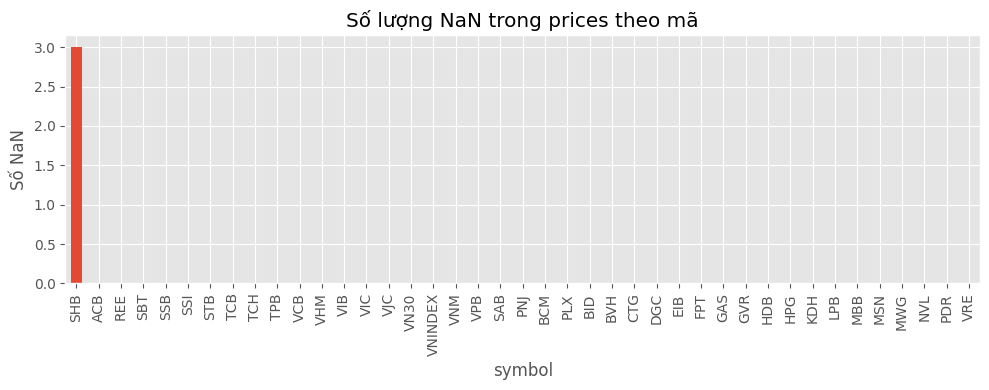

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Mã chứng khoán SHB khoảng trống dữ liệu, chủ yếu do chuyển sàn.
- Tuy nhiên phần lớn mã có số lượng NaN không quá lớn sau khi đã cắt ngày bắt đầu từ 24/03/2021.
- Việc nắm rõ mức độ missing giúp cân nhắc khi chọn tập mã để xây dựng mạng lưới và chạy các mô hình thống kê.
--------------------------------------------------------------------------------


In [39]:
missing_prices = prices.isna().sum()
missing_logret = log_returns.isna().sum()

print("🔹 Số lượng NaN trong prices (top 10):")
display(missing_prices.sort_values(ascending=False).head(10))

print("\n🔹 Số lượng NaN trong log_returns (top 10):")
display(missing_logret.sort_values(ascending=False).head(10))

plt.figure(figsize=(10,4))
missing_prices.sort_values(ascending=False).plot(kind="bar")
plt.title("Số lượng NaN trong prices theo mã")
plt.ylabel("Số NaN")
plt.tight_layout()
plt.show()

hline(
    "- Mã chứng khoán SHB khoảng trống dữ liệu, chủ yếu do chuyển sàn.\n"
    "- Tuy nhiên phần lớn mã có số lượng NaN không quá lớn sau khi đã cắt ngày bắt đầu từ 24/03/2021.\n"
    "- Việc nắm rõ mức độ missing giúp cân nhắc khi chọn tập mã để xây dựng mạng lưới và chạy các mô hình thống kê."
)

### Kiểm tra số ngày SHB bị thiếu

In [40]:
# Lấy danh sách tất cả ngày giao dịch trong dataset (sau khi đã lọc & xử lý)
all_days = df["time"].drop_duplicates().sort_values()

# Lấy danh sách ngày giao dịch của riêng mã SHB
shb_days = df.loc[df["symbol"] == "SHB", "time"].drop_duplicates().sort_values()

start_shb = shb_days.min()
all_days_from_shb = all_days[all_days >= start_shb]

# Các ngày bị thiếu của SHB
missing_days_shb = all_days_from_shb[~all_days_from_shb.isin(shb_days)]

print("Các ngày SHB bị thiếu:")
print(missing_days_shb)
print("Tổng số ngày thiếu:", len(missing_days_shb))

Các ngày SHB bị thiếu:
868   2021-10-06
870   2021-10-07
872   2021-10-08
Name: time, dtype: datetime64[ns]
Tổng số ngày thiếu: 3


## 6. Thống kê mô tả chi tiết (mean, std, skew, kurt, percentiles)

In [41]:
# Bỏ MARKET_EQ khỏi phần thống kê từng mã riêng lẻ
asset_cols = [c for c in log_returns.columns if c != "MARKET_EQ"]

desc = log_returns[asset_cols].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).T
desc["skew"] = log_returns[asset_cols].skew()
desc["kurtosis"] = log_returns[asset_cols].kurtosis()

print("🔹 Thống kê mô tả (một phần):")
display(desc.head())

top_vol = desc["std"].sort_values(ascending=False).head(7)
top_skew = desc["skew"].abs().sort_values(ascending=False).head(7)
top_kurt = desc["kurtosis"].sort_values(ascending=False).head(7)

print("\n- Top 7 Std cao nhất (biến động mạnh):")
display(top_vol)

print("\n- Top 7 |Skew| cao nhất (bất đối xứng):")
display(top_skew)

print("\n- Top  Kurtosis cao nhất (đuôi dày):")
display(top_kurt)

hline(
    "- Độ lệch chuẩn (Std) cho thấy có một số mã có biến động lợi suất vượt trội so với phần còn lại → rủi ro riêng lẻ cao.\n"
    "- Skewness lớn về trị tuyệt đối phản ánh sự bất đối xứng trong phân phối, thường gắn liền với các cú sốc lớn một chiều.\n"
    "- Kurtosis cao thể hiện phân phối đuôi dày (fat-tail), xác suất xuất hiện các phiên cực đoan cao hơn so với phân phối chuẩn.\n"
    "- Nhóm mã có Std và Kurtosis cao là ứng viên tiềm năng cho vai trò node quan trọng trong mạng lưới rủi ro."
)

🔹 Thống kê mô tả (một phần):


,count,mean,std,min,1%,5%,50%,95%,99%,max,skew,kurtosis
symbol,,,,,,,,,,,,
ACB,1157.0,0.000615,0.017055,-0.072200,-0.057462,-0.024188,0.000000,0.027898,0.055537,0.067086,-0.154579,4.098040
BCM,1157.0,0.000205,0.021617,-0.072456,-0.071329,-0.029887,0.000000,0.038067,0.067105,0.067747,0.031190,2.837158
BID,1157.0,0.000377,0.019699,-0.072455,-0.067686,-0.030081,0.000000,0.031495,0.058108,0.067879,-0.232510,2.778035
BVH,1157.0,0.000008,0.019612,-0.072458,-0.065393,-0.028183,0.000000,0.032072,0.059209,0.067490,-0.112617,2.734583
CTG,1157.0,0.000524,0.020348,-0.072366,-0.070551,-0.030786,0.000884,0.032349,0.059003,0.067815,-0.276520,2.573240



- Top 7 Std cao nhất (biến động mạnh):


symbol
TCH    0.029711
GVR    0.028046
PDR    0.027269
SSI    0.026762
NVL    0.026630
DGC    0.025876
EIB    0.025280
Name: std, dtype: float64


- Top 7 |Skew| cao nhất (bất đối xứng):


symbol
VNINDEX    0.927205
VJC        0.834820
VN30       0.748430
VIC        0.419019
GVR        0.383650
VNM        0.362297
MBB        0.335432
Name: skew, dtype: float64


- Top  Kurtosis cao nhất (đuôi dày):


symbol
SSB        5.035657
VNINDEX    4.882032
VJC        4.441687
VN30       4.386092
ACB        4.098040
VNM        3.825600
GAS        3.452299
Name: kurtosis, dtype: float64

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Độ lệch chuẩn (Std) cho thấy có một số mã có biến động lợi suất vượt trội so với phần còn lại → rủi ro riêng lẻ cao.
- Skewness lớn về trị tuyệt đối phản ánh sự bất đối xứng trong phân phối, thường gắn liền với các cú sốc lớn một chiều.
- Kurtosis cao thể hiện phân phối đuôi dày (fat-tail), xác suất xuất hiện các phiên cực đoan cao hơn so với phân phối chuẩn.
- Nhóm mã có Std và Kurtosis cao là ứng viên tiềm năng cho vai trò node quan trọng trong mạng lưới rủi ro.
--------------------------------------------------------------------------------


## 7. Boxplot toàn VN30 (phân phối lợi suất)

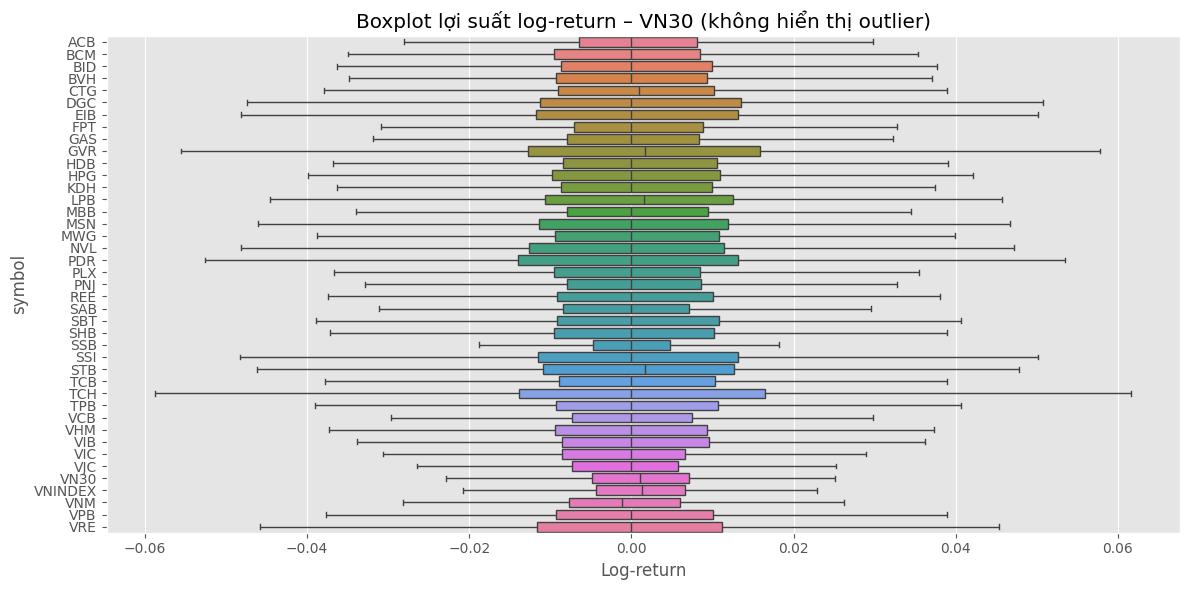

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Boxplot cho thấy phần lớn lợi suất nằm trong một dải hẹp quanh trung bình, nhưng vẫn tồn tại các đuôi phân phối dài.
- Sự khác biệt về độ rộng của box giữa các mã phản ánh mức độ biến động không đồng nhất trong rổ VN30.
- Các mã có box rộng và whisker dài thường là những cổ phiếu mang tính rủi ro cao và có khả năng gây nhiễu cho toàn hệ thống.
--------------------------------------------------------------------------------


In [42]:
plt.figure(figsize=(12,6))
sns.boxplot(data=log_returns[asset_cols], orient="h", showfliers=False)
plt.title("Boxplot lợi suất log-return – VN30 (không hiển thị outlier)")
plt.xlabel("Log-return")
plt.tight_layout()
plt.show()

hline(
    "- Boxplot cho thấy phần lớn lợi suất nằm trong một dải hẹp quanh trung bình, nhưng vẫn tồn tại các đuôi phân phối dài.\n"
    "- Sự khác biệt về độ rộng của box giữa các mã phản ánh mức độ biến động không đồng nhất trong rổ VN30.\n"
    "- Các mã có box rộng và whisker dài thường là những cổ phiếu mang tính rủi ro cao và có khả năng gây nhiễu cho toàn hệ thống."
)

## 8. Thanh khoản - Phân tích khối lượng giao dịch

- Thống kê volume theo mã (top 10):


,mean,median,max,sum
symbol,,,,
VNINDEX,7.122687e+08,660325150.0,2698901575,824807210605
VN30,2.299613e+08,198700762.5,1146147784,266295221208
SHB,2.751120e+07,16675785.0,249760712,31775441367
HPG,2.745566e+07,22295230.5,216265261,31793656520
SSI,2.022881e+07,16533430.0,105060505,23424963639
VPB,1.890031e+07,14887094.5,95597129,21886561437
STB,1.786747e+07,14895142.5,105105504,20690535981
MBB,1.580805e+07,12362325.5,117609377,18305720153
NVL,1.512040e+07,8837787.5,128536256,17509427490


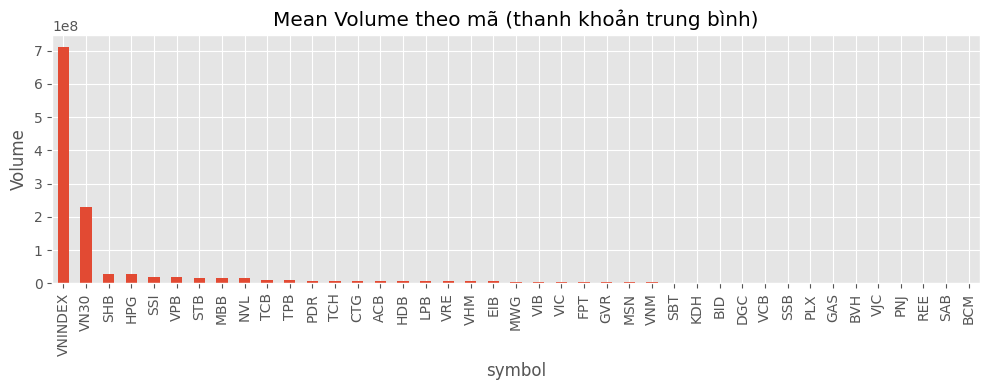

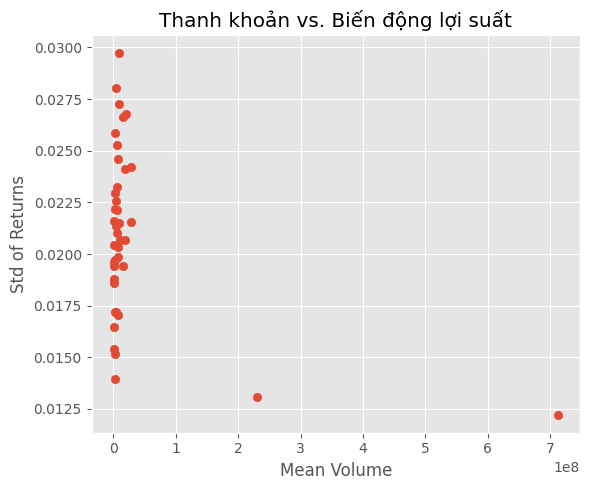

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Một số mã có thanh khoản vượt trội so với phần còn lại, thường là các bluechip đầu ngành.
- Thanh khoản cao kết hợp với độ biến động lớn khiến các mã này dễ trở thành kênh lan truyền thông tin và rủi ro.
- Mối tương quan dương giữa volume trung bình và độ biến động gợi ý vai trò đặc biệt của các cổ phiếu vừa 'to' vừa 'dao động mạnh'.
--------------------------------------------------------------------------------


In [43]:
vol_stats = df.groupby("symbol")["volume"].agg(["mean", "median", "max", "sum"]).sort_values("mean", ascending=False)

print("- Thống kê volume theo mã (top 10):")
display(vol_stats.head(10))

plt.figure(figsize=(10,4))
vol_stats["mean"].plot(kind="bar")
plt.title("Mean Volume theo mã (thanh khoản trung bình)")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()

# Liên hệ giữa thanh khoản và độ biến động
merged_vol_volatility = vol_stats.join(desc[["std"]])
plt.figure(figsize=(6,5))
plt.scatter(merged_vol_volatility["mean"], merged_vol_volatility["std"])
plt.xlabel("Mean Volume")
plt.ylabel("Std of Returns")
plt.title("Thanh khoản vs. Biến động lợi suất")
plt.tight_layout()
plt.show()

hline(
    "- Một số mã có thanh khoản vượt trội so với phần còn lại, thường là các bluechip đầu ngành.\n"
    "- Thanh khoản cao kết hợp với độ biến động lớn khiến các mã này dễ trở thành kênh lan truyền thông tin và rủi ro.\n"
    "- Mối tương quan dương giữa volume trung bình và độ biến động gợi ý vai trò đặc biệt của các cổ phiếu vừa 'to' vừa 'dao động mạnh'."
)

## 9. Histogram + kiểm định chuẩn chi tiết (một số mã tiêu biểu)

- Mã chọn phân tích phân phối: ['TCH', 'GVR', 'PDR', 'SSI', 'NVL', 'SSB', 'VNINDEX', 'VJC', 'VN30']


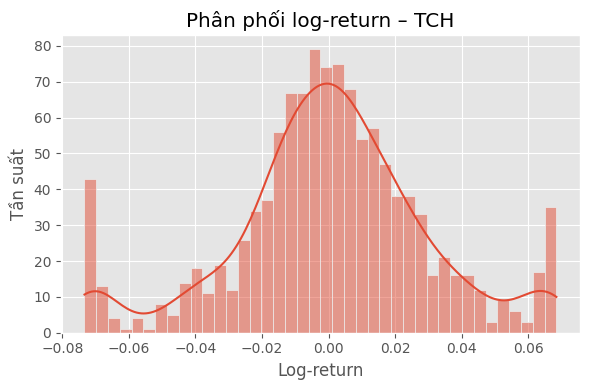


📌 Kiểm định chuẩn – TCH:
- Jarque-Bera: stat = 20.18, p-value = 0.00004
- Shapiro-Wilk: stat = 0.97, p-value = 0.00000


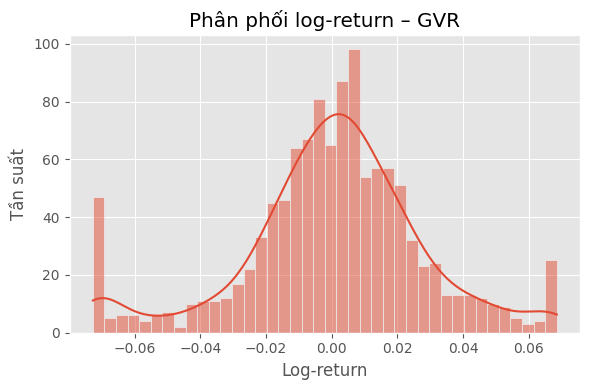


📌 Kiểm định chuẩn – GVR:
- Jarque-Bera: stat = 64.29, p-value = 0.00000
- Shapiro-Wilk: stat = 0.96, p-value = 0.00000


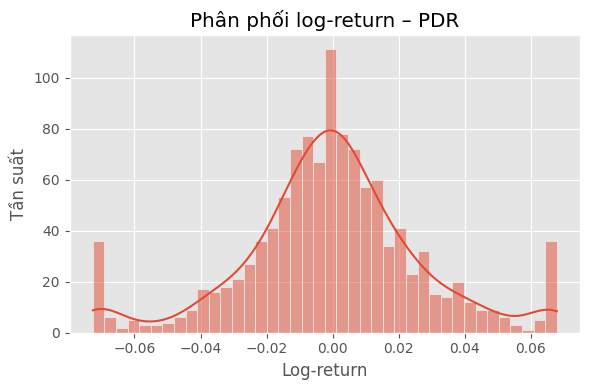


📌 Kiểm định chuẩn – PDR:
- Jarque-Bera: stat = 44.04, p-value = 0.00000
- Shapiro-Wilk: stat = 0.97, p-value = 0.00000


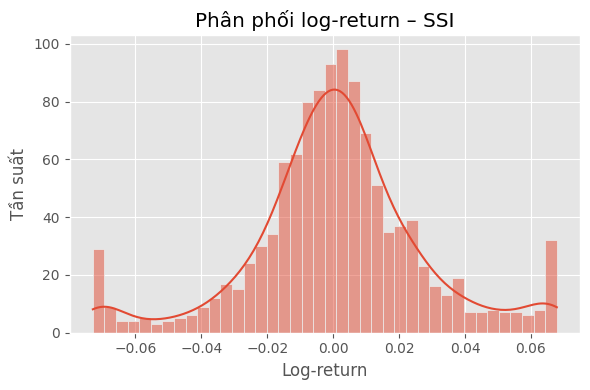


📌 Kiểm định chuẩn – SSI:
- Jarque-Bera: stat = 67.98, p-value = 0.00000
- Shapiro-Wilk: stat = 0.96, p-value = 0.00000


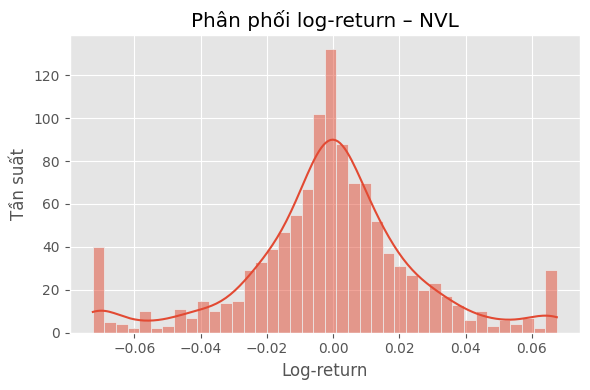


📌 Kiểm định chuẩn – NVL:
- Jarque-Bera: stat = 81.70, p-value = 0.00000
- Shapiro-Wilk: stat = 0.95, p-value = 0.00000


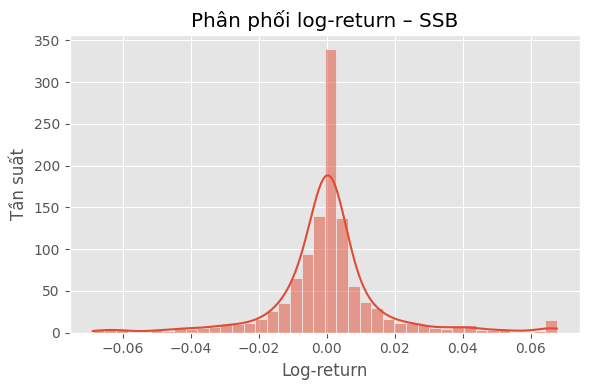


📌 Kiểm định chuẩn – SSB:
- Jarque-Bera: stat = 1230.44, p-value = 0.00000
- Shapiro-Wilk: stat = 0.85, p-value = 0.00000


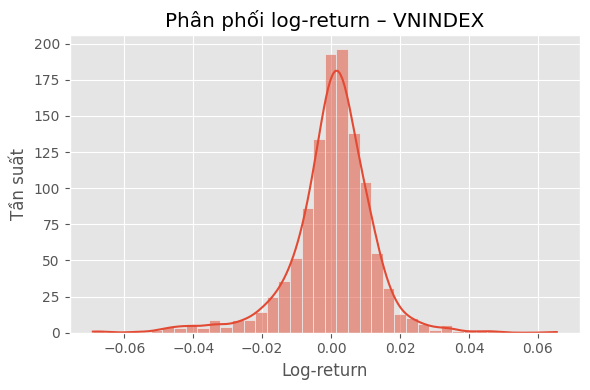


📌 Kiểm định chuẩn – VNINDEX:
- Jarque-Bera: stat = 1302.04, p-value = 0.00000
- Shapiro-Wilk: stat = 0.92, p-value = 0.00000


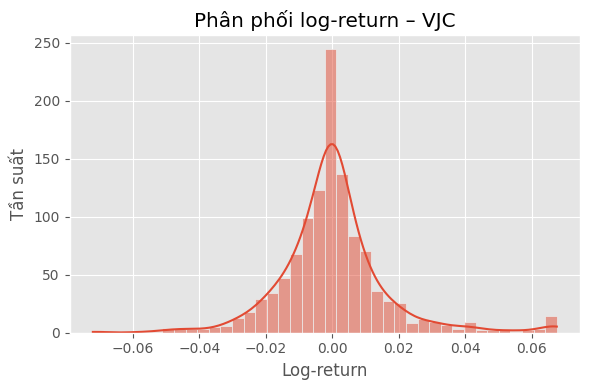


📌 Kiểm định chuẩn – VJC:
- Jarque-Bera: stat = 1074.72, p-value = 0.00000
- Shapiro-Wilk: stat = 0.90, p-value = 0.00000


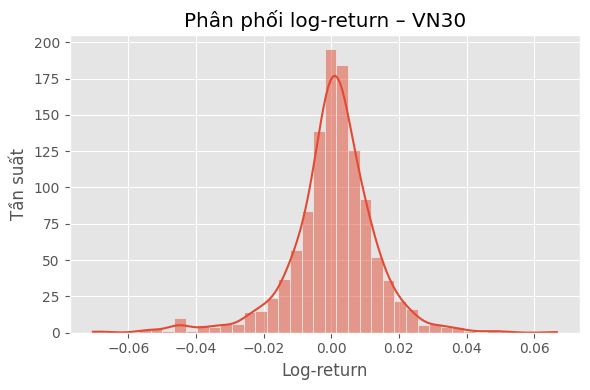


📌 Kiểm định chuẩn – VN30:
- Jarque-Bera: stat = 1024.99, p-value = 0.00000
- Shapiro-Wilk: stat = 0.93, p-value = 0.00000
--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Các kiểm định Jarque-Bera và Shapiro-Wilk cho nhóm mã tiêu biểu đều cho p-value rất nhỏ, bác bỏ giả thuyết phân phối chuẩn.
- Điều này phù hợp với quan sát trực quan từ histogram: phân phối lệch, đỉnh nhọn và đuôi dày.
- Kết quả củng cố luận điểm rằng việc sử dụng các giả định Gaussian thuần túy sẽ đánh giá thấp rủi ro cực đoan trên thị trường VN30.
--------------------------------------------------------------------------------


In [44]:
sample_tickers = list(top_vol.index[:5]) + list(top_kurt.index[:4])
sample_tickers = list(dict.fromkeys(sample_tickers))  # loại trùng

print("- Mã chọn phân tích phân phối:", sample_tickers)

for ticker in sample_tickers:
    series = log_returns[ticker].dropna()

    plt.figure(figsize=(6,4))
    sns.histplot(series, bins=40, kde=True)
    plt.title(f"Phân phối log-return – {ticker}")
    plt.xlabel("Log-return")
    plt.ylabel("Tần suất")
    plt.tight_layout()
    plt.show()

    jb_stat, jb_p = jarque_bera(series)
    sh_stat, sh_p = shapiro(series)

    print(f"\n📌 Kiểm định chuẩn – {ticker}:")
    print(f"- Jarque-Bera: stat = {jb_stat:.2f}, p-value = {jb_p:.5f}")
    print(f"- Shapiro-Wilk: stat = {sh_stat:.2f}, p-value = {sh_p:.5f}")

hline(
    "- Các kiểm định Jarque-Bera và Shapiro-Wilk cho nhóm mã tiêu biểu đều cho p-value rất nhỏ, bác bỏ giả thuyết phân phối chuẩn.\n"
    "- Điều này phù hợp với quan sát trực quan từ histogram: phân phối lệch, đỉnh nhọn và đuôi dày.\n"
    "- Kết quả củng cố luận điểm rằng việc sử dụng các giả định Gaussian thuần túy sẽ đánh giá thấp rủi ro cực đoan trên thị trường VN30."
)

## 10. Extreme returns (sự kiện tail risk 1% trên/dưới)

In [45]:
thr_low = log_returns[asset_cols].quantile(0.01)
thr_high = log_returns[asset_cols].quantile(0.99)

# Tìm các sự kiện cực đoan trên toàn thị trường
extreme_events = (log_returns[asset_cols].le(thr_low) | log_returns[asset_cols].ge(thr_high)).any(axis=1)
extreme_days = log_returns[extreme_events]

print("🔹 Một số ngày có extreme returns (top 10):")
display(extreme_days.head(10))

hline(
    "- Các ngày có extreme returns thể hiện những cú sốc lớn trên thị trường (crash hoặc rally mạnh).\n"
    "- Việc xác định và đánh dấu các phiên này giúp tập trung phân tích mạng lưới trong những giai đoạn mà rủi ro hệ thống bộc lộ rõ nhất.\n"
    "- Đây cũng là thời điểm để nghiên cứu cơ chế lan truyền (Granger causality) giữa các mã."
)

🔹 Một số ngày có extreme returns (top 10):


symbol,ACB,BCM,BID,BVH,CTG,DGC,EIB,FPT,GAS,GVR,HDB,HPG,KDH,LPB,MBB,MSN,MWG,NVL,PDR,PLX,PNJ,REE,SAB,SBT,SHB,SSB,SSI,STB,TCB,TCH,TPB,VCB,VHM,VIB,VIC,VJC,VN30,VNINDEX,VNM,VPB,VRE,MARKET_EQ
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-03-25,-0.013223,0.014295,0.002477,-0.001716,0.010260,0.002959,0.027106,-0.005068,0.002217,-0.019612,0.003704,-0.009966,0.000000,-0.002878,-0.002169,0.010420,-0.008461,0.002669,-0.008159,-0.001861,0.010558,-0.011019,-0.002801,-0.024251,-0.011205,0.067048,-0.015931,0.018843,0.001076,-0.004858,-0.001076,0.004357,-0.005039,-0.015580,0.022985,0.000781,-0.002444,0.001110,-0.002133,-0.018941,-0.016604,-0.000020
2021-03-26,0.013223,0.021345,-0.003718,-0.016937,-0.008734,-0.006352,0.000000,-0.006597,-0.012169,-0.010933,0.005530,0.026016,-0.029616,-0.013053,-0.002174,-0.001137,0.009424,-0.006239,-0.011180,-0.005187,-0.001034,0.011019,-0.011566,-0.007038,0.090175,0.067237,0.002915,0.010610,0.001075,-0.008969,-0.007564,-0.002176,-0.010439,0.003300,0.017875,0.018562,0.002187,-0.000765,-0.011140,0.002829,-0.019985,0.002236
2021-03-29,0.016287,0.008853,0.010704,0.013495,0.024116,0.051336,-0.005689,0.019366,0.003271,0.019826,0.010060,0.002565,0.013330,0.040063,0.026840,0.002272,0.000721,0.006239,0.007956,-0.005423,0.001034,0.005805,0.001701,0.002352,0.093319,0.067116,0.016601,0.013106,0.003754,0.036192,0.025697,0.004348,0.005233,0.016340,0.003597,0.008394,0.010975,0.011523,0.016332,0.025106,0.026055,0.016366
2021-03-30,0.008846,0.005128,0.007344,0.013505,0.009633,-0.029071,0.031290,-0.006216,0.001202,0.012622,0.007253,0.003069,0.000000,0.053255,0.002116,0.027560,-0.005543,0.008626,-0.003234,-0.001884,-0.005871,-0.020641,0.009865,0.007022,0.093924,0.066744,0.012095,0.065515,0.012766,0.017228,0.014691,-0.005317,0.000987,0.053641,0.036524,0.000000,0.009102,0.009043,0.001990,0.010278,-0.013709,0.012903
2021-03-31,0.000000,-0.005128,0.002030,-0.006634,-0.005917,-0.012963,0.030341,0.007690,0.001030,-0.014163,0.008097,0.007632,0.001588,0.003981,-0.005299,0.044266,0.002414,-0.002425,0.003234,-0.007150,0.000000,-0.011185,0.028070,0.008708,0.089765,0.065451,-0.001415,0.045300,0.008421,0.004648,0.001041,0.000000,0.010374,0.042111,0.007663,-0.014543,0.004508,0.004273,-0.008117,-0.006840,0.003063,0.008337
2021-04-01,0.016674,-0.001838,0.023257,0.021450,0.022011,0.023296,0.009912,0.025310,0.010067,0.022867,0.015118,0.035353,0.017820,0.002646,0.036519,-0.002247,0.034825,0.015986,0.019187,0.021506,0.011879,0.024307,-0.005469,0.022293,0.048558,0.002157,0.067103,0.006969,0.015085,0.057073,0.006224,0.021810,0.017284,0.030459,0.042409,0.021359,0.024704,0.020486,0.026109,0.027751,0.034564,0.021734
2021-04-05,0.003072,0.000000,0.011930,-0.017952,0.016807,0.000000,0.066424,-0.002298,-0.009930,0.000000,0.013793,0.004824,-0.019741,0.002608,0.025924,0.003288,-0.005116,0.041810,0.051336,-0.010554,0.001154,-0.001723,-0.002731,-0.009086,-0.104741,-0.005034,0.020111,0.024045,0.005628,0.013793,0.003066,0.042090,0.009924,0.050028,0.010463,0.000000,0.009542,0.009429,-0.001025,0.005291,0.019020,0.006577
2021-04-14,0.000000,0.000000,0.007949,-0.001679,0.016512,0.011614,0.068122,0.003681,0.005707,-0.007029,0.009374,0.056158,0.007651,0.002497,0.004796,0.066691,0.003702,0.035599,-0.002957,0.005282,0.008835,-0.005577,-0.003971,0.000000,0.011776,-0.018720,0.010057,0.008772,0.005076,-0.004326,0.001955,0.012411,-0.019654,0.005464,-0.004970,0.000758,0.010451,0.006022,-0.007124,0.007983,-0.008535,0.007535
2021-04-19,0.017558,0.014203,0.023367,0.027230,0.011634,0.041268,0.034097,0.022441,0.013855,0.019564,0.024563,0.057014,0.052446,0.023982,0.009852,0.067569,0.024886,0.009336,0.066667,-0.005743,0.033558,0.032813,0.005356,-0.018415,0.037200,0.006654,0.023530,0.035559,0.027866,0.017578,0.021729,0.022642,0.034081,0.020063,0.006977,0.001549,0.022726,0.017501,-0.008310,0.011820,0.000000,0.022257


--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Các ngày có extreme returns thể hiện những cú sốc lớn trên thị trường (crash hoặc rally mạnh).
- Việc xác định và đánh dấu các phiên này giúp tập trung phân tích mạng lưới trong những giai đoạn mà rủi ro hệ thống bộc lộ rõ nhất.
- Đây cũng là thời điểm để nghiên cứu cơ chế lan truyền (Granger causality) giữa các mã.
--------------------------------------------------------------------------------


## 11. Time-series log-return một số mã + MARKET_EQ

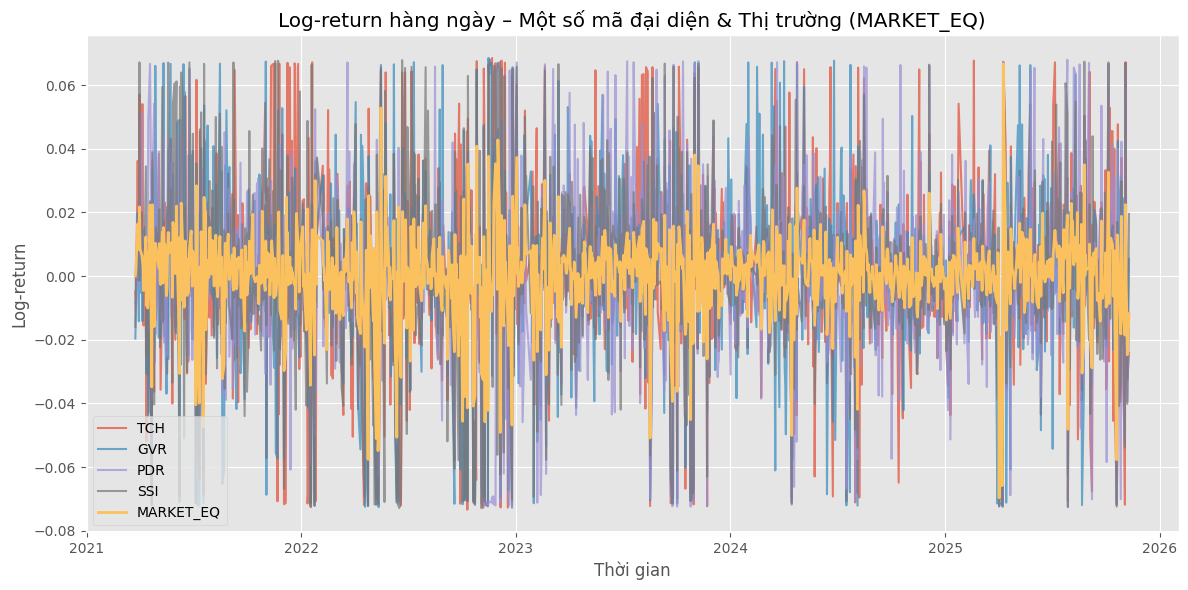

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Lợi suất của các mã đại diện biến động đồng pha với lợi suất chung của thị trường (MARKET_EQ), đặc biệt trong các giai đoạn biến động mạnh.
- Tuy nhiên vẫn tồn tại những pha phân hoá, khi một số mã biến động ngược chiều thị trường.
- Điều này gợi ý rằng cả yếu tố hệ thống và yếu tố riêng lẻ đều quan trọng trong động lực giá cổ phiếu VN30.
--------------------------------------------------------------------------------


In [46]:
rep_tickers = sample_tickers[:4]

plt.figure(figsize=(12,6))
for t in rep_tickers:
    plt.plot(log_returns.index, log_returns[t], label=t, alpha=0.7)

plt.plot(log_returns.index, log_returns["MARKET_EQ"], label="MARKET_EQ", linewidth=2)
plt.title("Log-return hàng ngày – Một số mã đại diện & Thị trường (MARKET_EQ)")
plt.xlabel("Thời gian")
plt.ylabel("Log-return")
plt.legend()
plt.tight_layout()
plt.show()

hline(
    "- Lợi suất của các mã đại diện biến động đồng pha với lợi suất chung của thị trường (MARKET_EQ), đặc biệt trong các giai đoạn biến động mạnh.\n"
    "- Tuy nhiên vẫn tồn tại những pha phân hoá, khi một số mã biến động ngược chiều thị trường.\n"
    "- Điều này gợi ý rằng cả yếu tố hệ thống và yếu tố riêng lẻ đều quan trọng trong động lực giá cổ phiếu VN30."
)

### 11.1. Chuỗi thời gian Log-return (làm mượt 5 ngày)

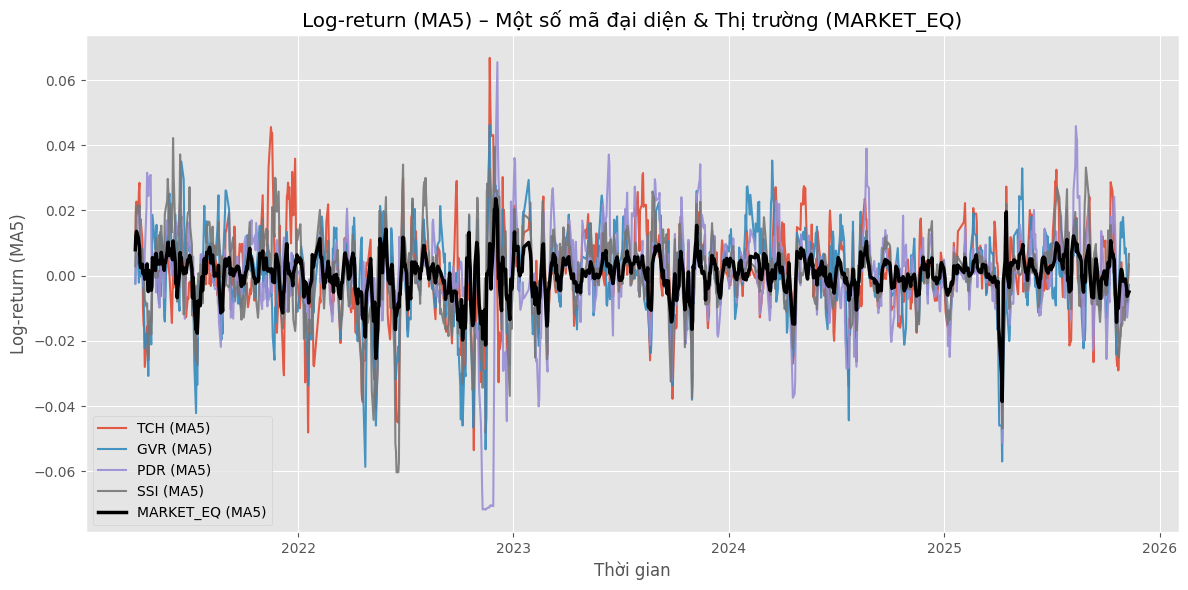

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Đường MA5 giúp làm mượt log-return, qua đó xu hướng biến động trở nên rõ ràng hơn.
- MARKET_EQ vẫn dao động quanh 0 nhưng bớt nhiễu, phản ánh rõ nhịp chung của thị trường.
- Các mã như ROS hoặc GVR thể hiện biên độ biến động lớn và nhiều pha lệch khỏi thị trường.
--------------------------------------------------------------------------------


In [47]:
rep_tickers = sample_tickers[:4]

plt.figure(figsize=(12,6))
for t in rep_tickers:
    plt.plot(
        log_returns.index,
        log_returns[t].rolling(5).mean(),
        label=f"{t} (MA5)",
        alpha=0.9
    )

plt.plot(
    log_returns.index,
    log_returns["MARKET_EQ"].rolling(5).mean(),
    label="MARKET_EQ (MA5)",
    linewidth=2.5,
    color="black"
)

plt.title("Log-return (MA5) – Một số mã đại diện & Thị trường (MARKET_EQ)")
plt.xlabel("Thời gian")
plt.ylabel("Log-return (MA5)")
plt.legend()
plt.tight_layout()
plt.show()

hline(
    "- Đường MA5 giúp làm mượt log-return, qua đó xu hướng biến động trở nên rõ ràng hơn.\n"
    "- MARKET_EQ vẫn dao động quanh 0 nhưng bớt nhiễu, phản ánh rõ nhịp chung của thị trường.\n"
    "- Các mã như ROS hoặc GVR thể hiện biên độ biến động lớn và nhiều pha lệch khỏi thị trường."
)

### 11.2. Subplots tách riêng

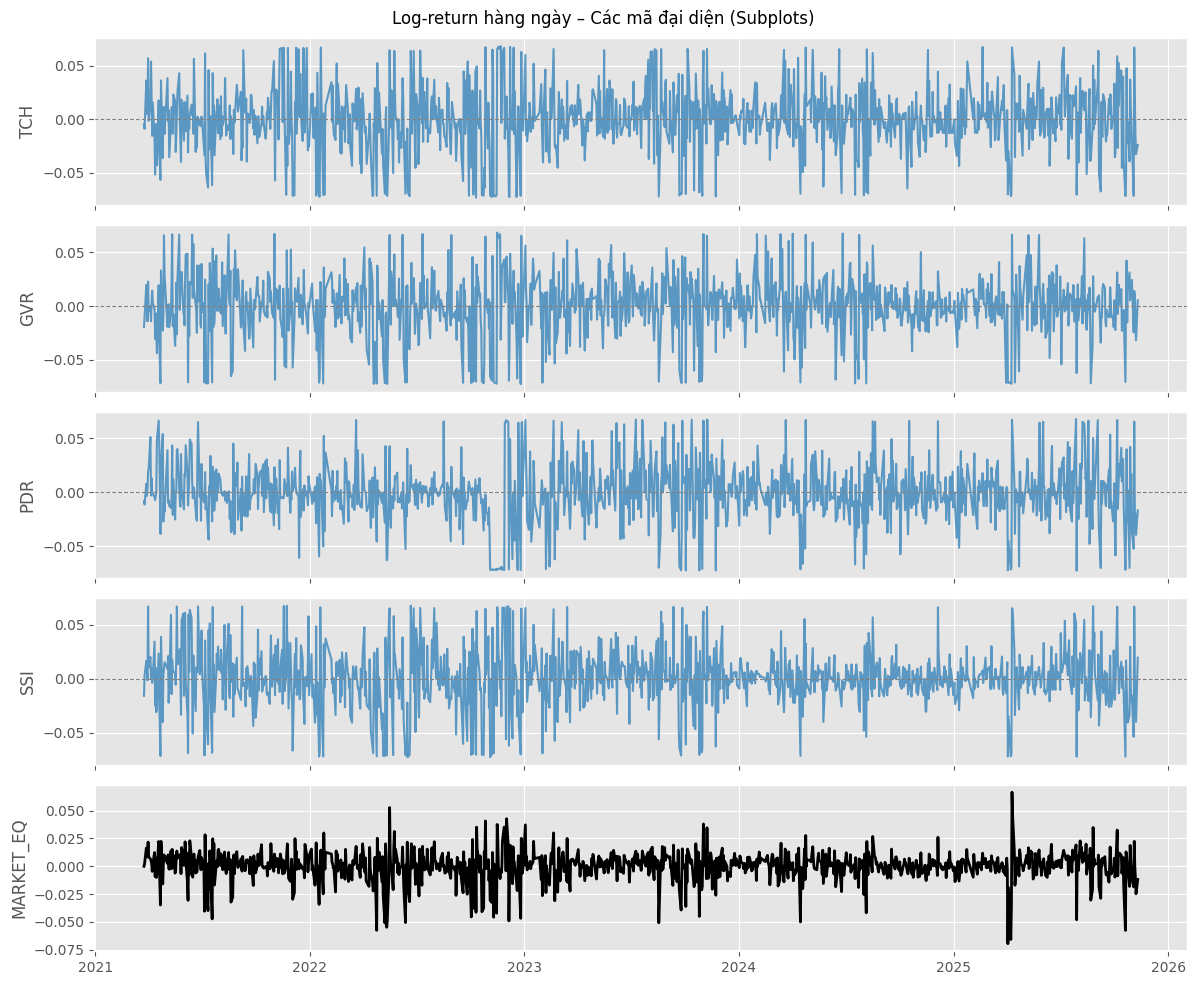

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Biểu đồ con (subplots) cho phép quan sát từng mã rõ ràng mà không bị nhiễu.
- MARKET_EQ thể hiện nhịp chung, trong khi các cổ phiếu riêng lẻ thể hiện mức độ phân hoá rõ rệt.
--------------------------------------------------------------------------------


In [48]:
rep_tickers = sample_tickers[:4]

fig, axes = plt.subplots(len(rep_tickers)+1, 1, figsize=(12,10), sharex=True)

for i, t in enumerate(rep_tickers):
    axes[i].plot(log_returns.index, log_returns[t], label=t, color="tab:blue", alpha=0.7)
    axes[i].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axes[i].set_ylabel(t)

axes[-1].plot(log_returns.index, log_returns["MARKET_EQ"], label="MARKET_EQ", color="black", linewidth=2)
axes[-1].set_ylabel("MARKET_EQ")

plt.suptitle("Log-return hàng ngày – Các mã đại diện (Subplots)")
plt.tight_layout()
plt.show()

hline(
    "- Biểu đồ con (subplots) cho phép quan sát từng mã rõ ràng mà không bị nhiễu.\n"
    "- MARKET_EQ thể hiện nhịp chung, trong khi các cổ phiếu riêng lẻ thể hiện mức độ phân hoá rõ rệt."
)

## 12. Rolling volatility (30 days) & Trạng thái thị trường biến động

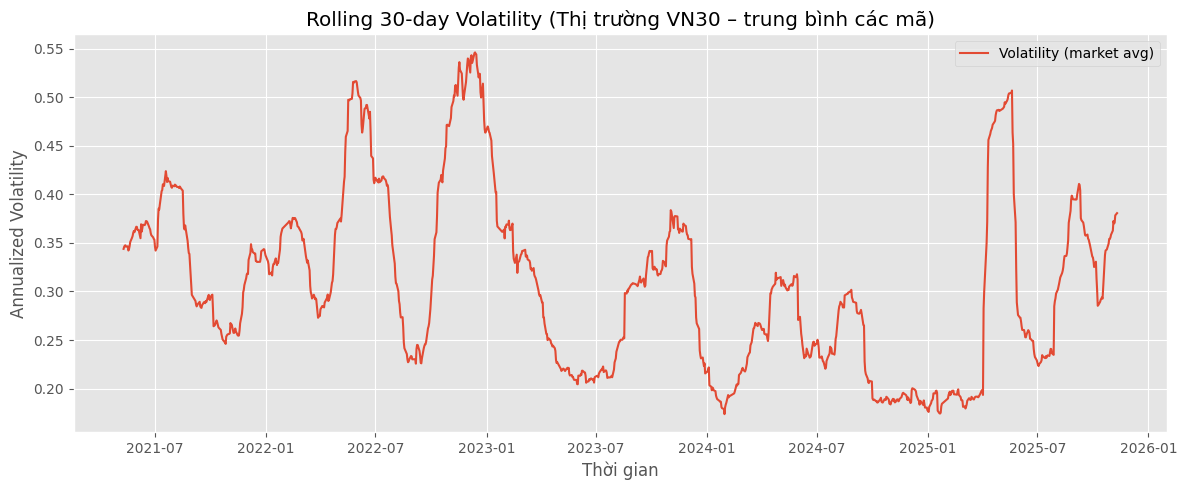

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Volatility trung bình của toàn bộ rổ VN30 thể hiện rõ các 'trạng thái thị trường' biến động cao và thấp theo thời gian.
- Giai đoạn volatility tăng vọt thường trùng với các sự kiện vĩ mô hoặc cú sốc tài chính.
- Đây chính là những thời kỳ mà rủi ro hệ thống và hiệu ứng lan truyền trên mạng lưới đóng vai trò quan trọng nhất.
--------------------------------------------------------------------------------


In [49]:
window = 30
rolling_vol = log_returns[asset_cols].rolling(window).std() * np.sqrt(252)
rolling_vol_market = rolling_vol.mean(axis=1)

plt.figure(figsize=(12,5))
plt.plot(rolling_vol_market.index, rolling_vol_market, label="Volatility (market avg)")
plt.title("Rolling 30-day Volatility (Thị trường VN30 – trung bình các mã)")
plt.xlabel("Thời gian")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.tight_layout()
plt.show()

hline(
    "- Volatility trung bình của toàn bộ rổ VN30 thể hiện rõ các 'trạng thái thị trường' biến động cao và thấp theo thời gian.\n"
    "- Giai đoạn volatility tăng vọt thường trùng với các sự kiện vĩ mô hoặc cú sốc tài chính.\n"
    "- Đây chính là những thời kỳ mà rủi ro hệ thống và hiệu ứng lan truyền trên mạng lưới đóng vai trò quan trọng nhất."
)

## 13. Ma trận tương quan & phân phối hệ số tương quan

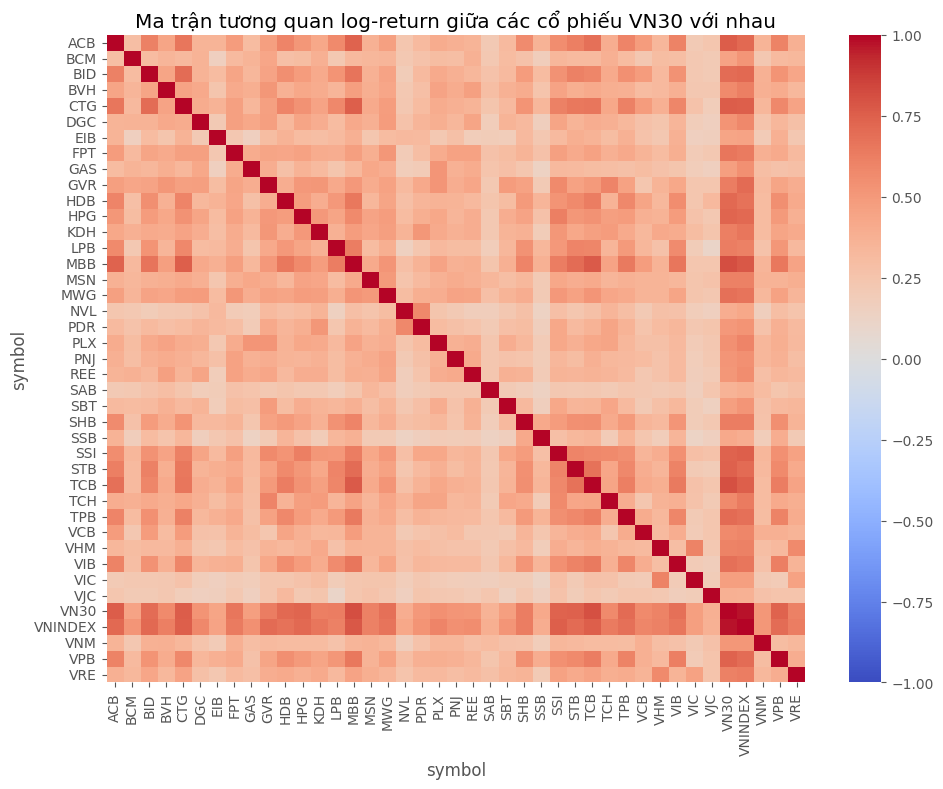

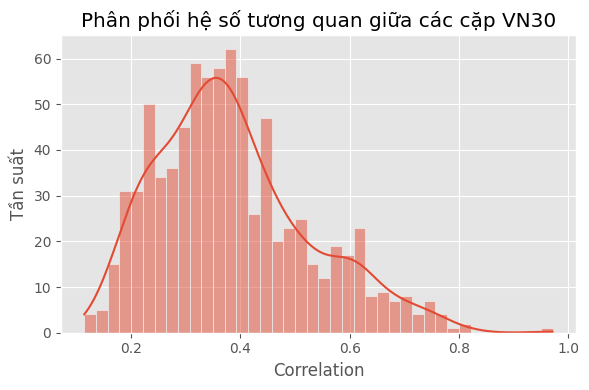

Số cặp: 820
Min corr: 0.11431743314857763
Max corr: 0.971207460843097
Mean corr: 0.38534517170425353
--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Hệ số tương quan trung bình dương cho thấy phần lớn các cổ phiếu VN30 có xu hướng đồng biến ở mức độ nhất định.
- Một số cặp mã có tương quan rất cao, phản ánh sự gắn kết mạnh mẽ và nguy cơ lan truyền rủi ro cao giữa chúng.
- Phân phối tương quan là cơ sở để lựa chọn ngưỡng (threshold) hợp lý khi xây dựng mạng lưới tương quan (correlation network).
--------------------------------------------------------------------------------


In [50]:
corr_matrix = log_returns[asset_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Ma trận tương quan log-return giữa các cổ phiếu VN30 với nhau")
plt.tight_layout()
plt.show()

corr_vals = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()

plt.figure(figsize=(6,4))
sns.histplot(corr_vals, bins=40, kde=True)
plt.title("Phân phối hệ số tương quan giữa các cặp VN30")
plt.xlabel("Correlation")
plt.ylabel("Tần suất")
plt.tight_layout()
plt.show()

print("Số cặp:", len(corr_vals))
print("Min corr:", corr_vals.min())
print("Max corr:", corr_vals.max())
print("Mean corr:", corr_vals.mean())

hline(
    "- Hệ số tương quan trung bình dương cho thấy phần lớn các cổ phiếu VN30 có xu hướng đồng biến ở mức độ nhất định.\n"
    "- Một số cặp mã có tương quan rất cao, phản ánh sự gắn kết mạnh mẽ và nguy cơ lan truyền rủi ro cao giữa chúng.\n"
    "- Phân phối tương quan là cơ sở để lựa chọn ngưỡng (threshold) hợp lý khi xây dựng mạng lưới tương quan (correlation network)."
)

### Tính tương quan giữa từng mã VN30 với VN30

- Tương quan từng mã với chỉ số VN30:


symbol
VN30       1.000000
VNINDEX    0.971207
MBB        0.817153
TCB        0.805643
CTG        0.762811
ACB        0.758543
STB        0.742884
SSI        0.740498
VPB        0.737904
HPG        0.730231
HDB        0.713104
TPB        0.705709
BID        0.696200
VIB        0.687049
MWG        0.685561
FPT        0.657954
LPB        0.631419
GVR        0.627880
SHB        0.627361
KDH        0.622233
VRE        0.616114
MSN        0.613493
VHM        0.604716
TCH        0.573598
BVH        0.571220
VCB        0.570706
PLX        0.543484
DGC        0.528227
PNJ        0.521549
VNM        0.513304
REE        0.509700
PDR        0.501617
VIC        0.476066
GAS        0.472538
SBT        0.470613
BCM        0.451486
EIB        0.440998
SSB        0.418895
NVL        0.397953
VJC        0.379111
SAB        0.366823
dtype: float64

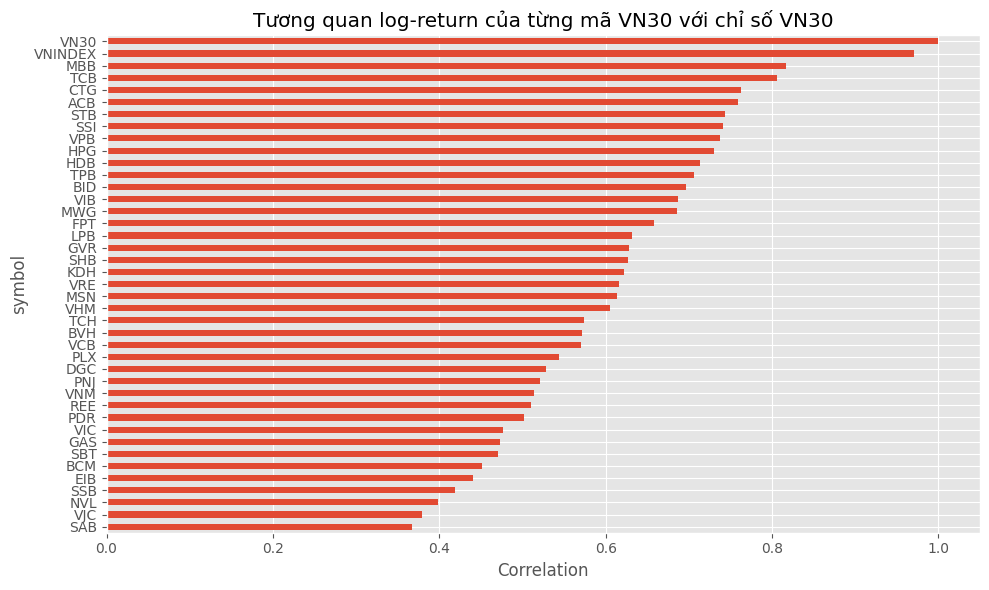

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Biểu đồ cho thấy phần lớn các mã trong rổ VN30 có mức độ tương quan khá cao với chỉ số VN30, phản ánh tính đồng pha chung của nhóm cổ phiếu vốn hóa lớn.
- Những mã có tương quan cao nhất (nhóm Top đầu) thường là các cổ phiếu dẫn dắt thị trường, có vốn hóa lớn hoặc thuộc các nhóm ngành nhạy cảm với chu kỳ thị trường (như ngân hàng, chứng khoán).
- Các mã có tương quan thấp hơn thể hiện hành vi giá mang tính riêng biệt thường đến từ đặc thù ngành, yếu tố nội tại doanh nghiệp.
- Mức độ phân hóa ở nhóm cuối cho thấy mặc dù cùng thuộc rổ VN30, nhưng không phải mã nào cũng đóng vai trò đại diện cho diễn biến của chỉ số.
- Đây là cơ sở tốt để lựa chọn mã đại diện,  đánh giá rủi ro hệ thống và hiểu cấu trúc vận động của nhóm VN30.
--------------------------------------------------------------------------------


In [51]:
corr_with_vn30 = log_returns[asset_cols].corrwith(log_returns["VN30"])

print("- Tương quan từng mã với chỉ số VN30:")
display(corr_with_vn30.sort_values(ascending=False))

# Vẽ barplot
plt.figure(figsize=(10,6))
corr_with_vn30.sort_values().plot(kind="barh")
plt.title("Tương quan log-return của từng mã VN30 với chỉ số VN30")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

hline(
    "- Biểu đồ cho thấy phần lớn các mã trong rổ VN30 có mức độ tương quan khá cao với chỉ số VN30, phản ánh tính đồng pha chung của nhóm cổ phiếu vốn hóa lớn.\n"
    "- Những mã có tương quan cao nhất (nhóm Top đầu) thường là các cổ phiếu dẫn dắt thị trường, có vốn hóa lớn hoặc thuộc các nhóm ngành nhạy cảm với chu kỳ thị trường (như ngân hàng, chứng khoán).\n"
    "- Các mã có tương quan thấp hơn thể hiện hành vi giá mang tính riêng biệt thường đến từ đặc thù ngành, yếu tố nội tại doanh nghiệp.\n"
    "- Mức độ phân hóa ở nhóm cuối cho thấy mặc dù cùng thuộc rổ VN30, nhưng không phải mã nào cũng đóng vai trò đại diện cho diễn biến của chỉ số.\n"
    "- Đây là cơ sở tốt để lựa chọn mã đại diện,  đánh giá rủi ro hệ thống và hiểu cấu trúc vận động của nhóm VN30."
)

### Tính tương quan giữa từng mã VN30 với VNINDEX

- Tương quan từng mã với VNINDEX:


symbol
VNINDEX    1.000000
VN30       0.971207
MBB        0.781159
CTG        0.757582
TCB        0.752040
SSI        0.750584
BID        0.718576
ACB        0.717971
HPG        0.715861
GVR        0.705755
STB        0.705560
VPB        0.695459
TPB        0.680022
HDB        0.673519
MWG        0.671519
VIB        0.662871
KDH        0.657159
TCH        0.639053
FPT        0.632939
SHB        0.631681
VRE        0.626792
BVH        0.620854
MSN        0.615108
VHM        0.610889
LPB        0.610247
PLX        0.598524
VCB        0.590706
DGC        0.580841
REE        0.555909
GAS        0.545738
PNJ        0.542973
PDR        0.528584
SBT        0.521002
BCM        0.518176
VNM        0.514282
VIC        0.473161
EIB        0.449659
NVL        0.422456
SSB        0.392707
SAB        0.389601
VJC        0.371588
dtype: float64

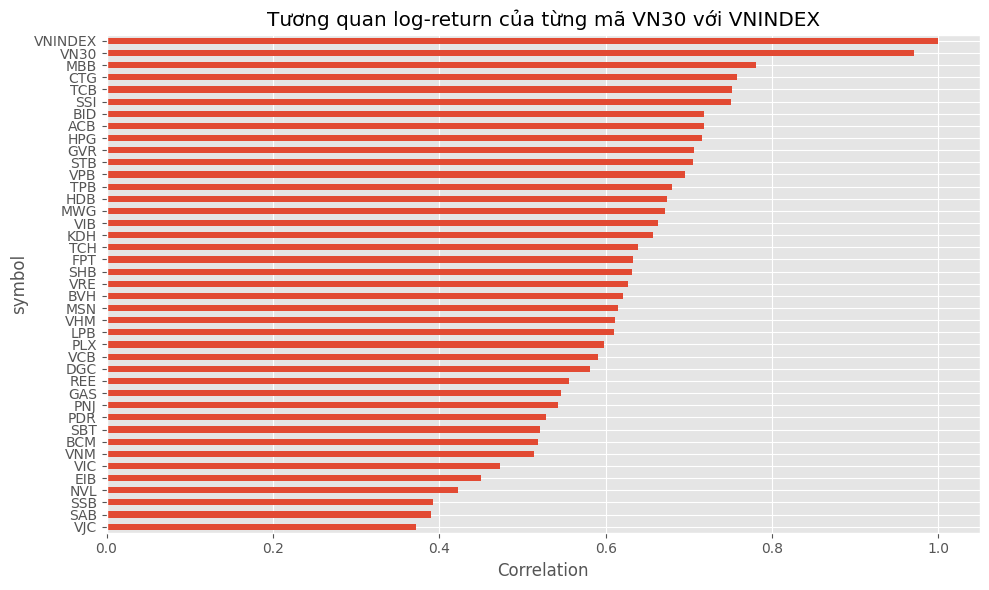

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Nhóm cổ phiếu ngân hàng như MBB, CTG, TCB, SSI, BID thể hiện tương quan rất cao với VNINDEX, cho thấy vai trò dẫn dắt và mức độ ảnh hưởng lớn tới xu hướng thị trường.
- Các bluechip như HPG, GVR, VPB, VHM, FPT cũng duy trì tương quan mạnh, phản ánh tính chất "market-driven" rõ rệt.
- Nhóm có tương quan thấp hơn gồm SAB, SSB, VJC, NVL… cho thấy biến động mang tính đặc thù ngành hoặc câu chuyện riêng, ít đồng pha với thị trường hơn.
- Phân phối tương quan trải đều từ khoảng ~0.4 đến ~0.8, cho thấy VN30 có cấu trúc nội tại đa dạng: một phần lớn bám sát thị trường, phần còn lại mang hành vi riêng biệt — hữu ích cho phân bổ danh mục và quản trị rủi ro.
--------------------------------------------------------------------------------


In [52]:
corr_with_vnindex = log_returns[asset_cols].corrwith(log_returns["VNINDEX"])

print("- Tương quan từng mã với VNINDEX:")
display(corr_with_vnindex.sort_values(ascending=False))

# Vẽ biểu đồ bar để so sánh
plt.figure(figsize=(10,6))
corr_with_vnindex.sort_values().plot(kind="barh")
plt.title("Tương quan log-return của từng mã VN30 với VNINDEX")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

hline(
    "- Nhóm cổ phiếu ngân hàng như MBB, CTG, TCB, SSI, BID thể hiện tương quan rất cao với VNINDEX, cho thấy vai trò dẫn dắt và mức độ ảnh hưởng lớn tới xu hướng thị trường.\n"
    "- Các bluechip như HPG, GVR, VPB, VHM, FPT cũng duy trì tương quan mạnh, phản ánh tính chất \"market-driven\" rõ rệt.\n"
    "- Nhóm có tương quan thấp hơn gồm SAB, SSB, VJC, NVL… cho thấy biến động mang tính đặc thù ngành hoặc câu chuyện riêng, ít đồng pha với thị trường hơn.\n"
    "- Phân phối tương quan trải đều từ khoảng ~0.4 đến ~0.8, cho thấy VN30 có cấu trúc nội tại đa dạng: một phần lớn bám sát thị trường, phần còn lại mang hành vi riêng biệt — hữu ích cho phân bổ danh mục và quản trị rủi ro."
)

## 14. Rolling correlation giữa 3 cặp mã tiêu biểu theo điều kiện
- Cùng ngành
- Khác ngành
- Độ biến động

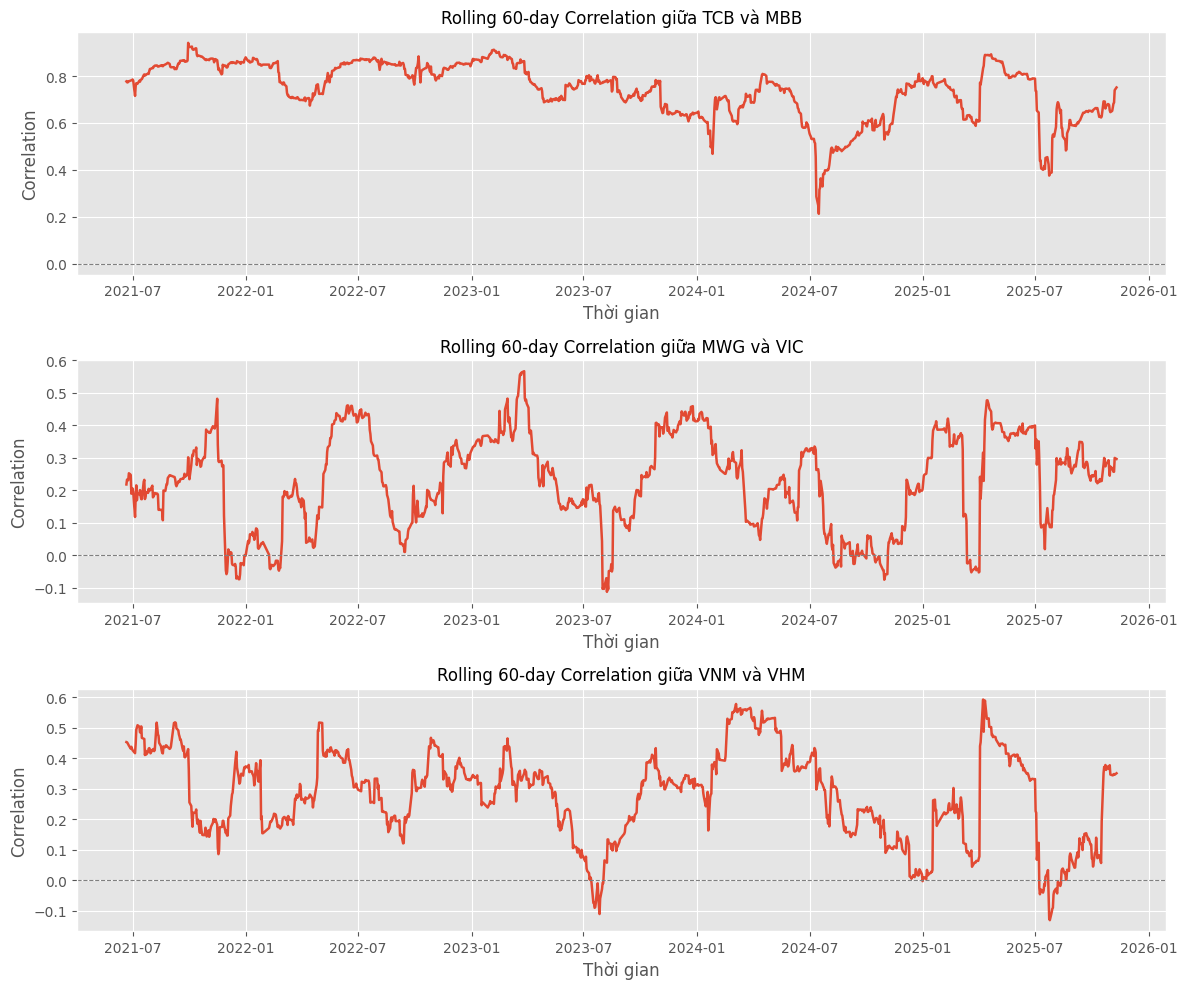

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Rolling correlation thể hiện mức độ đồng pha của từng cặp cổ phiếu thay đổi theo thời gian, không cố định.
- TCB-MBB (Ngân hàng) thường đồng pha mạnh do cùng chịu tác động chung từ chu kỳ của ngân hàng.
- MWG–VIC thể hiện sự phân hoá rõ rệt, phản ánh hai ngành ít liên hệ trực tiếp với nhau.
- VNM–VHM có mức độ tương quan dao động mạnh, cho thấy tác động riêng lẻ của từng ngành.
- Điều này cho thấy mạng lưới rủi ro mang tính động (dynamic network), cần xem xét theo từng cửa sổ thời gian.
--------------------------------------------------------------------------------


In [53]:
pair_list = [
    ("TCB", "MBB"),
    ("MWG", "VIC"),
    ("VNM", "VHM")
]

plt.figure(figsize=(12, 10))

for i, (t1, t2) in enumerate(pair_list, 1):
    plt.subplot(3, 1, i)

    rolling_corr = log_returns[t1].rolling(60).corr(log_returns[t2])

    plt.plot(rolling_corr.index, rolling_corr, linewidth=1.8)
    plt.title(f"Rolling 60-day Correlation giữa {t1} và {t2}", fontsize=12)
    plt.xlabel("Thời gian")
    plt.ylabel("Correlation")
    plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

hline(
    "- Rolling correlation thể hiện mức độ đồng pha của từng cặp cổ phiếu thay đổi theo thời gian, không cố định.\n"
    "- TCB-MBB (Ngân hàng) thường đồng pha mạnh do cùng chịu tác động chung từ chu kỳ của ngân hàng.\n"
    "- MWG–VIC thể hiện sự phân hoá rõ rệt, phản ánh hai ngành ít liên hệ trực tiếp với nhau.\n"
    "- VNM–VHM có mức độ tương quan dao động mạnh, cho thấy tác động riêng lẻ của từng ngành.\n"
    "- Điều này cho thấy mạng lưới rủi ro mang tính động (dynamic network), cần xem xét theo từng cửa sổ thời gian."
)

## 15. Tương quan theo giai đoạn (sub-periods) - So sánh trạng thái thị trường

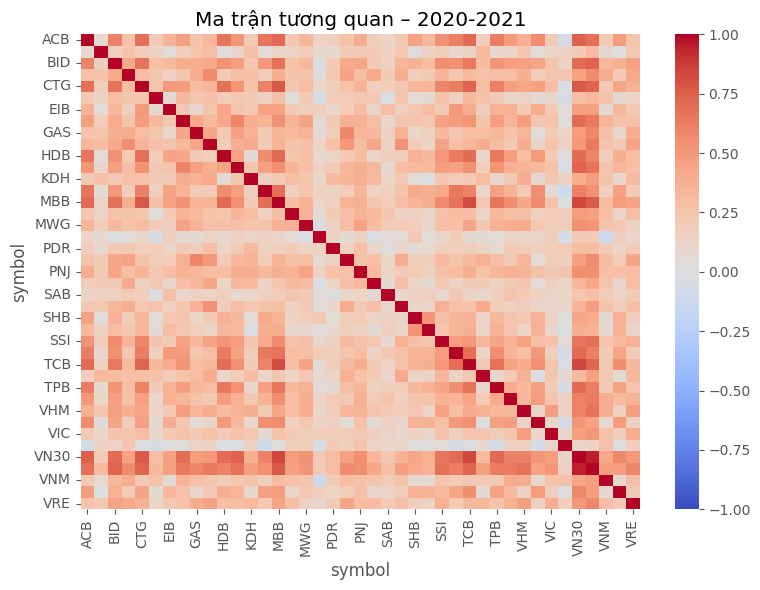

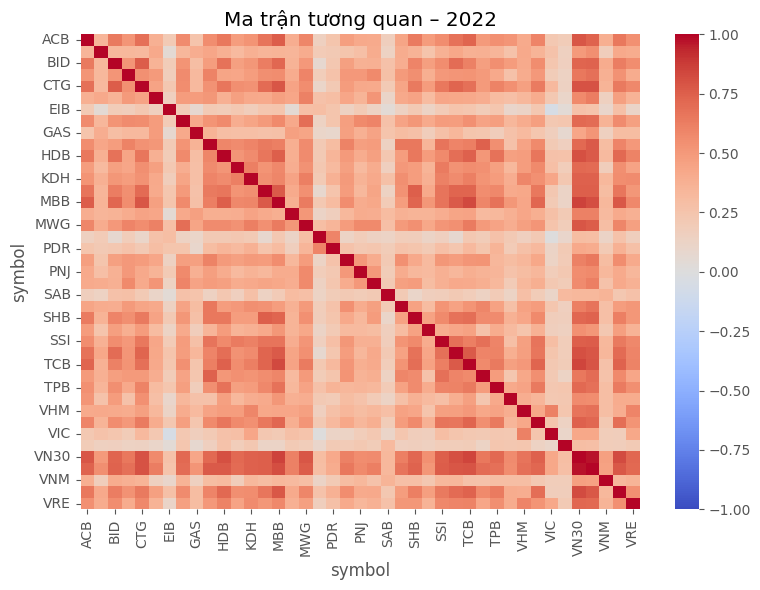

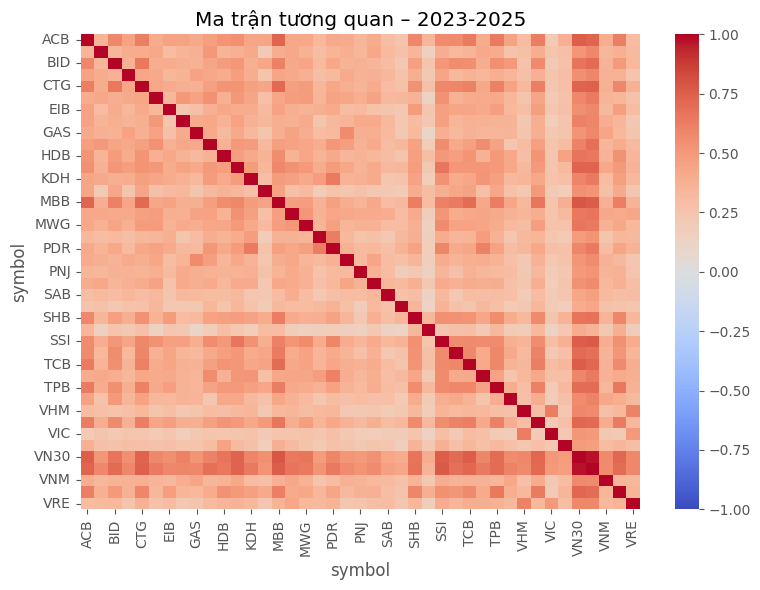

Mean correlation theo giai đoạn:
- 2020-2021: 0.293
- 2022: 0.419
- 2023-2025: 0.398
--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Mức độ tương quan trung bình thay đổi theo từng giai đoạn, thường cao hơn trong các giai đoạn thị trường căng thẳng.
- Giai đoạn có mean correlation cao cho thấy rủi ro hệ thống nổi trội, khi các cổ phiếu cùng phản ứng mạnh theo một chiều.
- Kết quả này gợi ý nên xây dựng mạng lưới riêng cho từng giai đoạn để so sánh cấu trúc rủi ro hệ thống.
--------------------------------------------------------------------------------


In [54]:
periods = {
    "2020-2021": ("2020-01-06", "2021-12-31"),
    "2022": ("2022-01-01", "2022-12-31"),
    "2023-2025": ("2023-01-01", log_returns.index.max().strftime("%Y-%m-%d"))
}

mean_corr_by_period = {}

for label, (start, end) in periods.items():
    sub = log_returns.loc[start:end, asset_cols]
    if len(sub) < 50:
        continue
    sub_corr = sub.corr()
    vals = sub_corr.where(np.triu(np.ones(sub_corr.shape), k=1).astype(bool)).stack()
    mean_corr_by_period[label] = vals.mean()

    plt.figure(figsize=(8,6))
    sns.heatmap(sub_corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title(f"Ma trận tương quan – {label}")
    plt.tight_layout()
    plt.show()

print("Mean correlation theo giai đoạn:")
for k, v in mean_corr_by_period.items():
    print(f"- {k}: {v:.3f}")

hline(
    "- Mức độ tương quan trung bình thay đổi theo từng giai đoạn, thường cao hơn trong các giai đoạn thị trường căng thẳng.\n"
    "- Giai đoạn có mean correlation cao cho thấy rủi ro hệ thống nổi trội, khi các cổ phiếu cùng phản ứng mạnh theo một chiều.\n"
    "- Kết quả này gợi ý nên xây dựng mạng lưới riêng cho từng giai đoạn để so sánh cấu trúc rủi ro hệ thống."
)

## 16. Phân tích theo ngành

### 16.1. Phân tích Volatility & Intra-Sector Correlation theo ngành

In [66]:
sector_map = df.drop_duplicates(subset=["symbol"])[["symbol", "industry"]].set_index("symbol")["industry"]
sector_series = sector_map[asset_cols]

print("🔹 Một số mã & ngành:")
display(sector_series.head(10))

sector_vol = {}
sector_corr = {}

for sector in sector_series.unique():
    tickers = sector_series[sector_series == sector].index.intersection(asset_cols)
    if len(tickers) <= 1:
        continue
    sub_ret = log_returns[tickers]
    sector_vol[sector] = sub_ret.std().mean()
    corr_mat = sub_ret.corr()
    vals = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool)).stack()
    sector_corr[sector] = vals.mean()

print("\nVolatility trung bình theo ngành:")
display(pd.Series(sector_vol).sort_values(ascending=False))

print("\nMean correlation nội bộ theo ngành:")
display(pd.Series(sector_corr).sort_values(ascending=False))

hline(
    "- Một số ngành có volatility trung bình cao hơn hẳn, phản ánh mức độ rủi ro nội tại lớn hơn (ví dụ: ngành chu kỳ, ngành nhạy cảm vĩ mô).\n"
    "- Một số ngành khác có tương quan nội bộ rất cao, cho thấy các cổ phiếu trong ngành vận động gần như 'một khối'.\n"
    "- Các ngành vừa có volatility cao vừa có tương quan nội bộ mạnh là những cụm rủi ro quan trọng trong mạng lưới hệ thống."
)

🔹 Một số mã & ngành:


symbol
ACB              Banks
BCM        Real Estate
BID              Banks
BVH          Insurance
CTG              Banks
DGC          Chemicals
EIB              Banks
FPT         Technology
GAS    Oil, Gas & Coal
GVR          Chemicals
Name: industry, dtype: object


Volatility trung bình theo ngành:


Chemicals                   0.026961
Real Estate                 0.024133
Banks                       0.020682
Food, Beverage & Tobacco    0.019830
Oil, Gas & Coal             0.019013
Retail                      0.018771
dtype: float64


Mean correlation nội bộ theo ngành:


Oil, Gas & Coal             0.519020
Banks                       0.512537
Chemicals                   0.473215
Real Estate                 0.363257
Retail                      0.323240
Food, Beverage & Tobacco    0.307396
dtype: float64

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Một số ngành có volatility trung bình cao hơn hẳn, phản ánh mức độ rủi ro nội tại lớn hơn (ví dụ: ngành chu kỳ, ngành nhạy cảm vĩ mô).
- Một số ngành khác có tương quan nội bộ rất cao, cho thấy các cổ phiếu trong ngành vận động gần như 'một khối'.
- Các ngành vừa có volatility cao vừa có tương quan nội bộ mạnh là những cụm rủi ro quan trọng trong mạng lưới hệ thống.
--------------------------------------------------------------------------------


In [65]:
sector_map = df.drop_duplicates(subset=["symbol"])[["symbol", "industry"]].set_index("symbol")["industry"]
sector_series = sector_map[asset_cols]

sector_vol = {}
sector_corr = {}

for sector in sector_series.unique():
    tickers = sector_series[sector_series == sector].index.intersection(asset_cols)

    if len(tickers) == 0:
        continue

    sub_ret = log_returns[tickers]

    if len(tickers) == 1:
        sector_vol[sector] = sub_ret.std().iloc[0]
        sector_corr[sector] = np.nan
    else:
        sector_vol[sector] = sub_ret.std().mean()
        corr_mat = sub_ret.corr()
        vals = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool)).stack()
        sector_corr[sector] = vals.mean()

df_sector = pd.DataFrame({
    "vol": pd.Series(sector_vol),
    "corr": pd.Series(sector_corr)
}).reset_index().rename(columns={"index": "sector"})


### 16.2. Phân tích tương quan chéo giữa các ngành (Inter-Sector Correlation)

/tmp/ipykernel_549/1149423012.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  sector_returns = log_returns[asset_cols].groupby(sector_series, axis=1).mean()


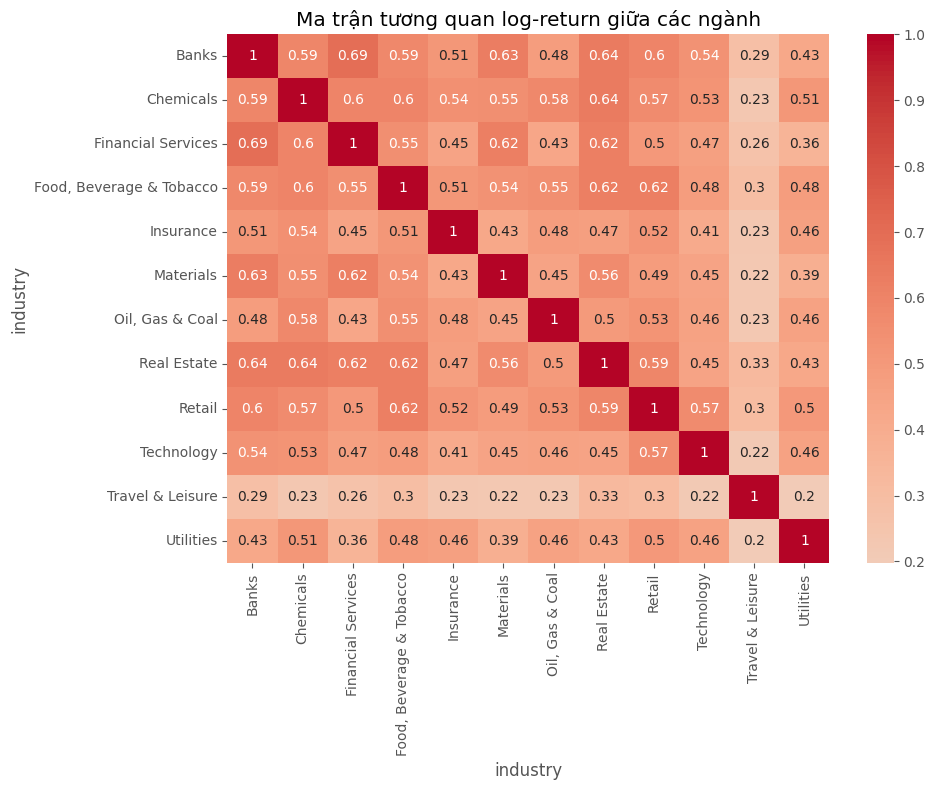

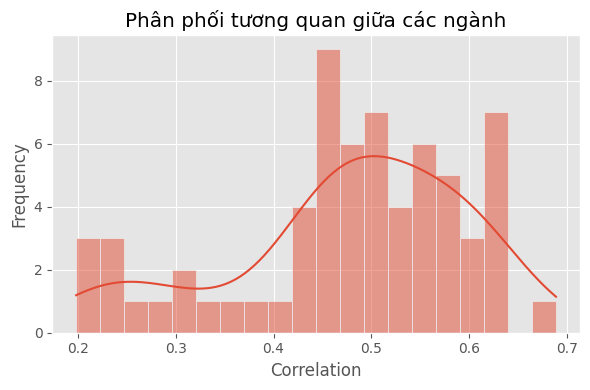

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Ma trận tương quan giữa các ngành cho thấy mức độ đồng pha của từng nhóm ngành trên toàn thị trường.
- Một số ngành có mức tương quan cao (Banking, Real Estate) phản ánh sự liên kết mạnh mẽ về chu kỳ kinh tế.
- Các ngành có mức tương quan thấp hơn hoạt động độc lập hơn, ít chịu tác động chéo từ thị trường.

--------------------------------------------------------------------------------


In [57]:
# Tính sector return (equal-weight)
sector_returns = log_returns[asset_cols].groupby(sector_series, axis=1).mean()

# Ma trận tương quan giữa các ngành
sector_corr_mat = sector_returns.corr()

plt.figure(figsize=(10,8))
sns.heatmap(sector_corr_mat, annot=True, cmap="coolwarm", center=0)
plt.title("Ma trận tương quan log-return giữa các ngành")
plt.tight_layout()
plt.show()

# Histogram của các cặp ngành
vals = sector_corr_mat.where(
    np.triu(np.ones(sector_corr_mat.shape), k=1).astype(bool)
).stack()

plt.figure(figsize=(6,4))
sns.histplot(vals, bins=20, kde=True)
plt.title("Phân phối tương quan giữa các ngành")
plt.xlabel("Correlation")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

hline(
    "- Ma trận tương quan giữa các ngành cho thấy mức độ đồng pha của từng nhóm ngành trên toàn thị trường.\n"
    "- Một số ngành có mức tương quan cao (Banking, Real Estate) phản ánh sự liên kết mạnh mẽ về chu kỳ kinh tế.\n"
    "- Các ngành có mức tương quan thấp hơn hoạt động độc lập hơn, ít chịu tác động chéo từ thị trường.\n"
)

### 16.3. Biến động tổng hợp theo ngành

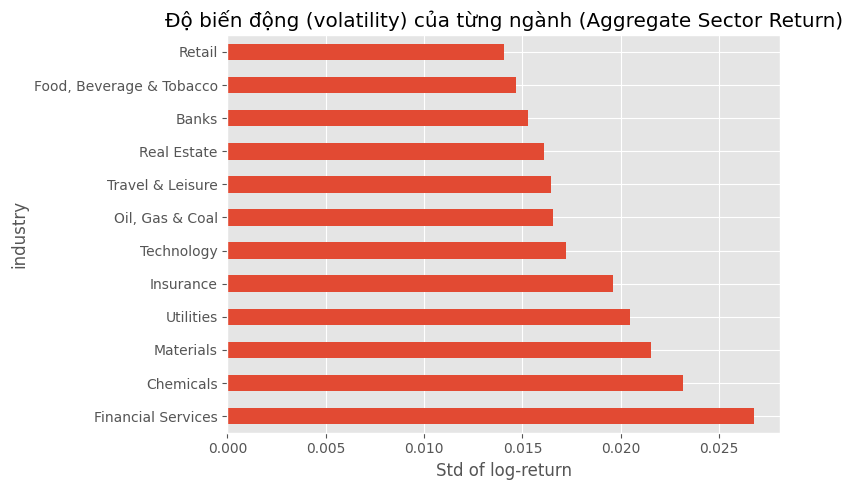

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Volatility tổng hợp cho thấy ngành Financial Services biến động mạnh nhất trên toàn kỳ.
- Các ngành chu kỳ (như Chemicals, Materials) thường có biến động lớn hơn, phản ánh sự nhạy cảm với thị trường.
- Ngành có volatility thấp (như Retail, Food, Beverage & Tobacco) thường mang tính phòng thủ, ít rủi ro hệ thống.
- Đây là bước quan trọng để xác định các ngành 'đầu tàu rủi ro' (dẫn dắt thị trường) trong mạng lưới sau này.
--------------------------------------------------------------------------------


In [58]:
sector_vol_agg = sector_returns.std().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sector_vol_agg.plot(kind="barh")
plt.title("Độ biến động (volatility) của từng ngành (Aggregate Sector Return)")
plt.xlabel("Std of log-return")
plt.tight_layout()
plt.show()

hline(
    "- Volatility tổng hợp cho thấy ngành Financial Services biến động mạnh nhất trên toàn kỳ.\n"
    "- Các ngành chu kỳ (như Chemicals, Materials) thường có biến động lớn hơn, phản ánh sự nhạy cảm với thị trường.\n"
    "- Ngành có volatility thấp (như Retail, Food, Beverage & Tobacco) thường mang tính phòng thủ, ít rủi ro hệ thống.\n"
    "- Đây là bước quan trọng để xác định các ngành 'đầu tàu rủi ro' (dẫn dắt thị trường) trong mạng lưới sau này."
)

### 16.4. Rolling Mean (20D) của Top 5 Ngành Biến Động Mạnh Nhất

<Figure size 1200x600 with 0 Axes>

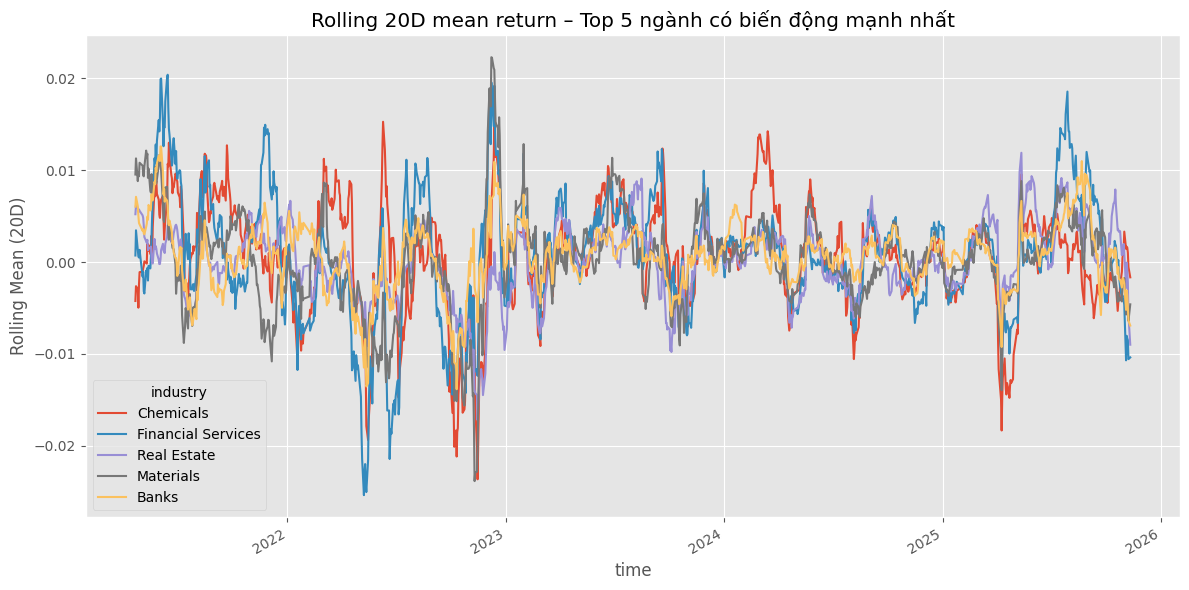

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Biểu đồ thể hiện Rolling Mean 20 ngày của 5 ngành có mức biến động mạnh nhất, giúp quan sát xu hướng ngắn hạn và mức độ đồng pha giữa các ngành.
- Có thể thấy các ngành có tính chu kỳ như Financial Services, Real Estate và Materials thường biến động mạnh và nhạy với các cú sốc thị trường, thể hiện qua các pha rơi đồng loạt vào đầu 2023 và cuối 2025.
- Trong khi đó, Banks có xu hướng ổn định hơn tương đối.
- Các ngành dù khác nhau nhưng phần lớn vẫn cho thấy mức độ đồng pha nhất định, phản ánh ảnh hưởng chung của điều kiện vĩ mô và tâm lý thị trường.
- Những giai đoạn mà một ngành tăng/giảm sớm hơn phần còn lại có thể là dấu hiệu của vai trò dẫn dắt (early mover), hữu ích cho phân tích lan truyền rủi ro và quan hệ nhân quả giữa các ngành sau này.
--------------------------------------------------------------------------------


In [59]:
top_sectors = (
    df_sector.sort_values("vol", ascending=False)
             .dropna(subset=["vol"])
             .head(5)["sector"]
)

plt.figure(figsize=(12,6))
sector_returns[top_sectors].rolling(20).mean().plot(figsize=(12,6))
plt.title("Rolling 20D mean return – Top 5 ngành có biến động mạnh nhất")
plt.ylabel("Rolling Mean (20D)")
plt.tight_layout()
plt.show()

hline(
    "- Biểu đồ thể hiện Rolling Mean 20 ngày của 5 ngành có mức biến động mạnh nhất, giúp quan sát xu hướng ngắn hạn và mức độ đồng pha giữa các ngành.\n"
    "- Có thể thấy các ngành có tính chu kỳ như Financial Services, Real Estate và Materials thường biến động mạnh và nhạy với các cú sốc thị trường, thể hiện qua các pha rơi đồng loạt vào đầu 2023 và cuối 2025.\n"
    "- Trong khi đó, Banks có xu hướng ổn định hơn tương đối.\n"
    "- Các ngành dù khác nhau nhưng phần lớn vẫn cho thấy mức độ đồng pha nhất định, phản ánh ảnh hưởng chung của điều kiện vĩ mô và tâm lý thị trường.\n"
    "- Những giai đoạn mà một ngành tăng/giảm sớm hơn phần còn lại có thể là dấu hiệu của vai trò dẫn dắt (early mover), hữu ích cho phân tích lan truyền rủi ro và quan hệ nhân quả giữa các ngành sau này."
)

### 16.4. Scatterplot, mối quan hệ giữa độ biến động trung bình (volatility) và mức độ gắn kết nội bộ ngành (intra-sector correlation)

🔹 Một số mã & ngành:


symbol
ACB              Banks
BCM        Real Estate
BID              Banks
BVH          Insurance
CTG              Banks
DGC          Chemicals
EIB              Banks
FPT         Technology
GAS    Oil, Gas & Coal
GVR          Chemicals
Name: industry, dtype: object

📌 Bảng volatility & intra-sector correlation theo ngành:


,sector,vol,corr
0,Banks,0.020682,0.512537
1,Real Estate,0.024133,0.363257
2,Insurance,0.019612,NaN
3,Chemicals,0.026961,0.473215
4,Technology,0.017214,NaN
5,"Oil, Gas & Coal",0.019013,0.519020
6,Materials,0.021542,NaN
7,"Food, Beverage & Tobacco",0.019830,0.307396
8,Retail,0.018771,0.323240
9,Utilities,0.020457,NaN


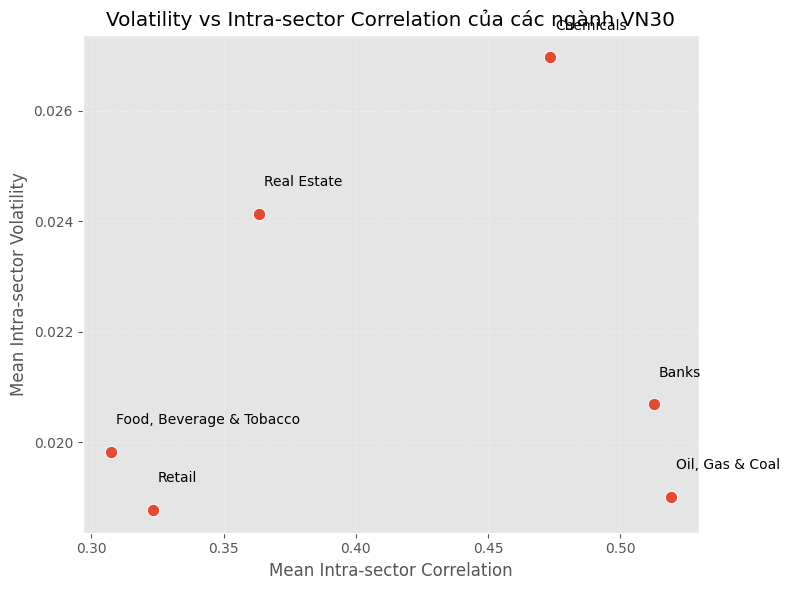

📎 Ngành chỉ có 1 mã (không tính được correlation): ['Insurance', 'Technology', 'Materials', 'Utilities', 'Financial Services', 'Travel & Leisure']
--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Scatterplot thể hiện mối quan hệ giữa độ biến động trung bình (volatility) và mức độ gắn kết nội bộ ngành (intra-sector correlation).
- Các ngành nằm phía trên, bên phải (vol cao, corr cao) là các cụm rủi ro tập trung, có khả năng lan truyền biến động mạnh.
- Các ngành vol thấp, corr thấp nằm phía dưới, bên trái mang tính phòng thủ hơn.
- Những ngành chỉ có 1 cổ phiếu trong VN30 không thể tính được tương quan nội bộ, nhưng volatility vẫn hữu ích để đánh giá mức rủi ro.

--------------------------------------------------------------------------------


In [60]:
sector_map = df.drop_duplicates(subset=["symbol"])[["symbol", "industry"]].set_index("symbol")["industry"]
sector_series = sector_map[asset_cols]

print("🔹 Một số mã & ngành:")
display(sector_series.head(10))


# --- 2. Tính volatility & intra-sector correlation ---
sector_vol = {}
sector_corr = {}

for sector in sector_series.unique():
    tickers = sector_series[sector_series == sector].index.intersection(asset_cols)

    if len(tickers) == 0:
        continue  # ngành không có cổ phiếu nào trong bộ VN30

    sub_ret = log_returns[tickers]

    # Ngành có 1 mã → tính vol, corr = NaN
    if len(tickers) == 1:
        sector_vol[sector] = sub_ret.std().iloc[0]
        sector_corr[sector] = np.nan
    else:
        # Ngành có >= 2 mã → tính cả vol và corr
        sector_vol[sector] = sub_ret.std().mean()
        corr_mat = sub_ret.corr()
        vals = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool)).stack()
        sector_corr[sector] = vals.mean()


# --- 3. Tạo bảng kết quả ---
df_sector = pd.DataFrame({
    "vol": pd.Series(sector_vol),
    "corr": pd.Series(sector_corr)
}).reset_index().rename(columns={"index": "sector"})

print("📌 Bảng volatility & intra-sector correlation theo ngành:")
display(df_sector)


# --- 4. Chỉ scatter các ngành có ≥2 mã (corr != NaN) ---
df_scatter = df_sector.dropna(subset=["corr"])

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_scatter, x="corr", y="vol", s=80)

# Annotate tên ngành
for i, row in df_scatter.iterrows():
    plt.text(row["corr"] + 0.002, row["vol"] + 0.0005, row["sector"], fontsize=10)

plt.xlabel("Mean Intra-sector Correlation")
plt.ylabel("Mean Intra-sector Volatility")
plt.title("Volatility vs Intra-sector Correlation của các ngành VN30")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


# --- 5. Ngành chỉ có 1 mã ---
single_sector_list = df_sector[df_sector["corr"].isna()]["sector"].tolist()
print("📎 Ngành chỉ có 1 mã (không tính được correlation):", single_sector_list)


hline(
    "- Scatterplot thể hiện mối quan hệ giữa độ biến động trung bình (volatility) và mức độ gắn kết nội bộ ngành (intra-sector correlation).\n"
    "- Các ngành nằm phía trên, bên phải (vol cao, corr cao) là các cụm rủi ro tập trung, có khả năng lan truyền biến động mạnh.\n"
    "- Các ngành vol thấp, corr thấp nằm phía dưới, bên trái mang tính phòng thủ hơn.\n"
    "- Những ngành chỉ có 1 cổ phiếu trong VN30 không thể tính được tương quan nội bộ, nhưng volatility vẫn hữu ích để đánh giá mức rủi ro.\n"
)

## 17. PCA: Yếu tố hệ thống & tỷ lệ giải thích phương sai

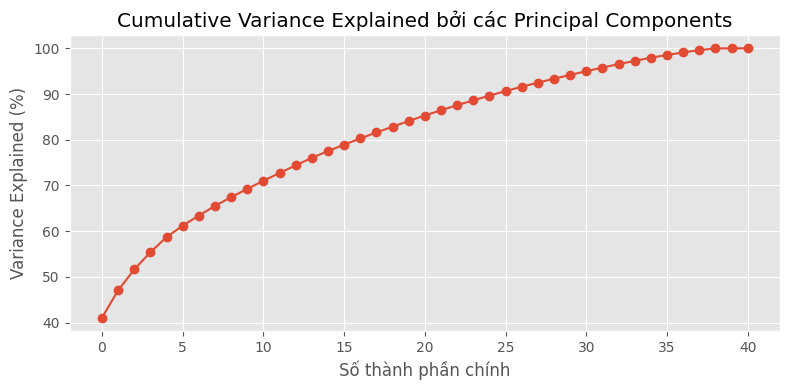

Variance explained bởi PC1: 41.04224375214016 %
--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Thành phần chính đầu tiên (PC1) thường giải thích một tỉ lệ lớn phương sai, phản ánh yếu tố thị trường chung (systematic factor).
- Nếu PC1 chiếm tỉ lệ rất cao, điều đó cho thấy thị trường chịu chi phối mạnh bởi một yếu tố hệ thống.
- Các thành phần sau (PC2, PC3,...) phản ánh các yếu tố ngành hoặc nhóm cổ phiếu cụ thể hơn.
--------------------------------------------------------------------------------


In [61]:
from sklearn.decomposition import PCA

# Chuẩn bị dữ liệu: bỏ NaN theo hàng
X = log_returns[asset_cols].dropna(how="any").values

pca = PCA()
pca.fit(X)

explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(8,4))
plt.plot(np.cumsum(explained_var)*100, marker="o")
plt.xlabel("Số thành phần chính")
plt.ylabel("Variance Explained (%)")
plt.title("Cumulative Variance Explained bởi các Principal Components")
plt.tight_layout()
plt.show()

print("Variance explained bởi PC1:", explained_var[0]*100, "%")

hline(
    "- Thành phần chính đầu tiên (PC1) thường giải thích một tỉ lệ lớn phương sai, phản ánh yếu tố thị trường chung (systematic factor).\n"
    "- Nếu PC1 chiếm tỉ lệ rất cao, điều đó cho thấy thị trường chịu chi phối mạnh bởi một yếu tố hệ thống.\n"
    "- Các thành phần sau (PC2, PC3,...) phản ánh các yếu tố ngành hoặc nhóm cổ phiếu cụ thể hơn."
)

## 18. ACF/PACF - Kiểm tra tự tương quan trong lợi suất

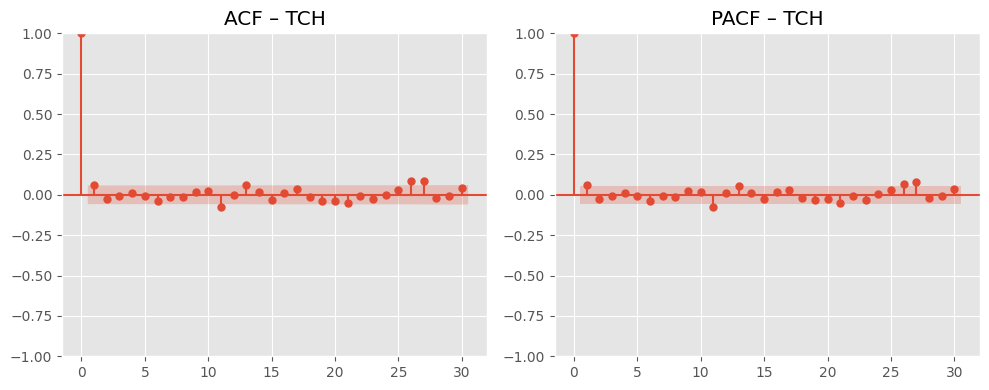

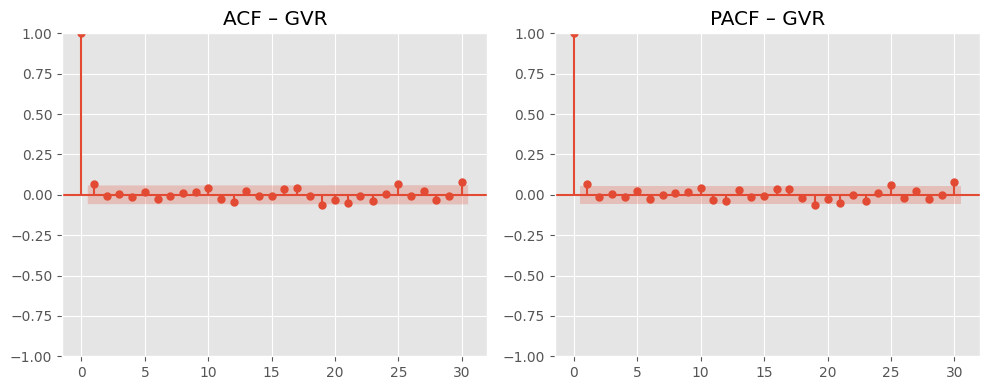

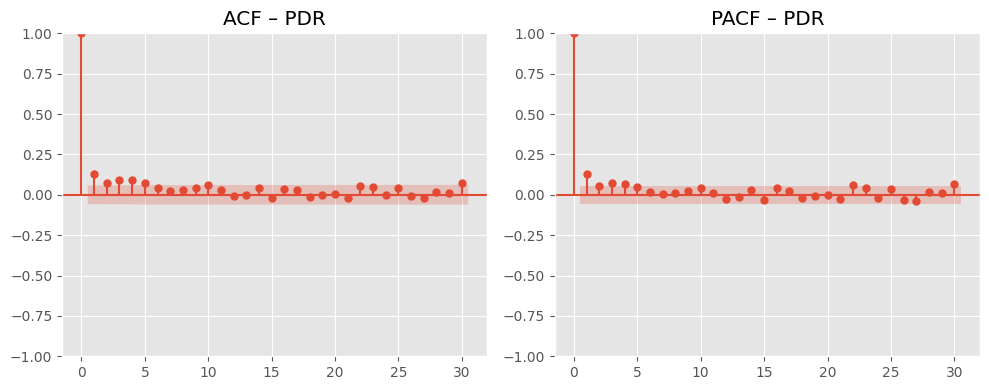

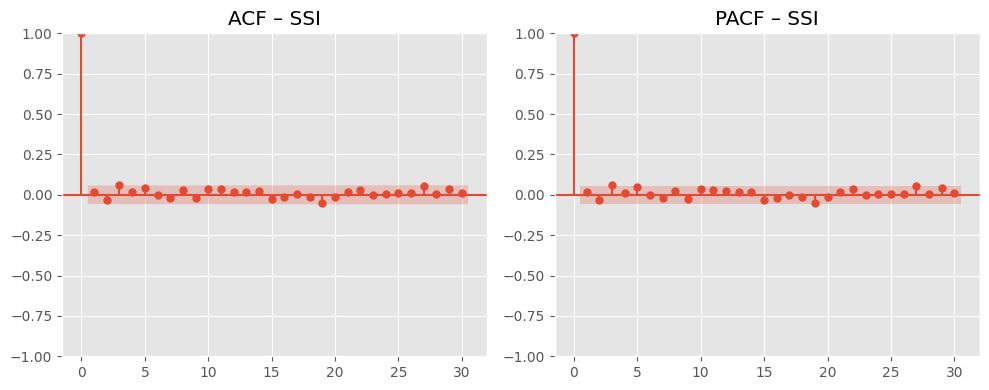

--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- ACF và PACF cho thấy tự tương quan trong chuỗi lợi suất thường không quá mạnh, phù hợp với giả định thị trường tương đối hiệu quả trong ngắn hạn.
- Tuy nhiên một số độ trễ có ý nghĩa thống kê, gợi ý khả năng khai thác mô hình động (VAR, Granger) để phân tích quan hệ nhân quả giữa các mã.
- Kết quả này hỗ trợ trực tiếp cho bước xây dựng mô hình Granger causality trong phần phân tích mạng có hướng.
--------------------------------------------------------------------------------


In [62]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sample_for_acf = rep_tickers[:4]

for ticker in sample_for_acf:
    series = log_returns[ticker].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    plot_acf(series, ax=axes[0], lags=30, title=f"ACF – {ticker}")
    plot_pacf(series, ax=axes[1], lags=30, title=f"PACF – {ticker}")
    plt.tight_layout()
    plt.show()

hline(
    "- ACF và PACF cho thấy tự tương quan trong chuỗi lợi suất thường không quá mạnh, phù hợp với giả định thị trường tương đối hiệu quả trong ngắn hạn.\n"
    "- Tuy nhiên một số độ trễ có ý nghĩa thống kê, gợi ý khả năng khai thác mô hình động (VAR, Granger) để phân tích quan hệ nhân quả giữa các mã.\n"
    "- Kết quả này hỗ trợ trực tiếp cho bước xây dựng mô hình Granger causality trong phần phân tích mạng có hướng."
)

## 19. ADF Test (Tính dừng của lợi suất)

In [63]:
adf_results = []
for ticker in asset_cols:
    series = log_returns[ticker].dropna()
    try:
        stat, p_value, _, _, _, _ = adfuller(series, autolag="AIC")
        adf_results.append((ticker, stat, p_value))
    except:
        adf_results.append((ticker, np.nan, np.nan))

adf_df = pd.DataFrame(adf_results, columns=["Ticker", "ADF_stat", "p_value"]).set_index("Ticker")

print("🔹 ADF test (một phần):")
display(adf_df.head())

print("\nSố mã có p < 0.05 (chuỗi dừng):", (adf_df["p_value"] < 0.05).sum(), "/", len(adf_df))

hline(
    "- Hầu hết các chuỗi lợi suất log-return cho kết quả p-value ADF nhỏ hơn 0.05, hàm ý tính dừng theo nghĩa yếu.\n"
    "- Điều này là điều kiện quan trọng để đảm bảo tính hợp lệ của các kiểm định nhân quả Granger.\n"
    "- Kết quả củng cố rằng dữ liệu lợi suất thích hợp cho việc xây dựng mô hình VAR/Granger giữa các cổ phiếu VN30."
)

🔹 ADF test (một phần):


,ADF_stat,p_value
Ticker,,
ACB,-20.878767,0.000000e+00
BCM,-10.116885,9.671667e-18
BID,-15.279939,4.592586e-28
BVH,-18.186894,2.424907e-30
CTG,-25.597342,0.000000e+00



Số mã có p < 0.05 (chuỗi dừng): 41 / 41
--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Hầu hết các chuỗi lợi suất log-return cho kết quả p-value ADF nhỏ hơn 0.05, hàm ý tính dừng theo nghĩa yếu.
- Điều này là điều kiện quan trọng để đảm bảo tính hợp lệ của các kiểm định nhân quả Granger.
- Kết quả củng cố rằng dữ liệu lợi suất thích hợp cho việc xây dựng mô hình VAR/Granger giữa các cổ phiếu VN30.
--------------------------------------------------------------------------------


## 20. Tail Risk - Var & Expected Shortfall cho #10 mã biến động mạnh nhất


In [64]:
alpha = 0.95
q = 1 - alpha

# Lấy 10 mã có Std cao nhất
tail_tickers = desc["std"].sort_values(ascending=False).head(10).index.tolist()

var_es_list = []
for ticker in tail_tickers:
    series = log_returns[ticker].dropna()
    var = series.quantile(q)
    es = series[series <= var].mean()
    var_es_list.append((ticker, var, es))

var_es_df = pd.DataFrame(var_es_list, columns=["Ticker", "VaR_95", "ES_95"]).set_index("Ticker")
print("🔹 VaR & Expected Shortfall (95%) – Top 10 mã Std cao nhất:")
display(var_es_df)

hline(
    "- Phân tích tail risk được áp dụng cho 10 mã có độ biến động lớn nhất (Std cao).\n"
    "- Những mã này thường nhạy cảm nhất với các sự kiện cực đoan và có khả năng tạo cú sốc lan truyền.\n"
    "- VaR và ES càng âm cho thấy mức độ rủi ro cực đoan càng lớn, quan trọng trong phân tích rủi ro hệ thống."
)

🔹 VaR & Expected Shortfall (95%) – Top 10 mã Std cao nhất:


,VaR_95,ES_95
Ticker,,
TCH,-0.063975,-0.070667
GVR,-0.061319,-0.070309
PDR,-0.048415,-0.066982
SSI,-0.048319,-0.065992
NVL,-0.056142,-0.068288
DGC,-0.041892,-0.063240
EIB,-0.040286,-0.060745
LPB,-0.037836,-0.057794
SHB,-0.036328,-0.060329


--------------------------------------------------------------------------------
📌 KẾT LUẬN / DIỄN GIẢI:
- Phân tích tail risk được áp dụng cho 10 mã có độ biến động lớn nhất (Std cao).
- Những mã này thường nhạy cảm nhất với các sự kiện cực đoan và có khả năng tạo cú sốc lan truyền.
- VaR và ES càng âm cho thấy mức độ rủi ro cực đoan càng lớn, quan trọng trong phân tích rủi ro hệ thống.
--------------------------------------------------------------------------------
